# Часть 1

## Подготовка среды

In [ ]:
import os
import sys
import random
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Настройка для работы с очень большими изображениями
Image.MAX_IMAGE_PIXELS = None

In [ ]:
print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA available: True
CUDA version: 12.8
Device name: Tesla T4


In [ ]:
# Фиксация Seed
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

In [ ]:
# Создание структуры папок
folders = [
    # Исходные данные
    'data/raw',

    # Промежуточные данные
    'data/interim',

    # Финальные датасеты
    'data/processed',

    # Разбиение: .csv или .json файлы со списками имен файлов
    'splits',

    # Веса моделей: здесь сохраняются файлы .pt
    'artifacts/checkpoints',

    # Предсказания
    'artifacts/preds',

    # Отчеты
    'artifacts/reports',

    # Визуализация
    'artifacts/figures'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"Created: {folder}")

!rm -rf sample_data
!rm -rf checkpoints

Created: data/raw
Created: data/interim
Created: data/processed
Created: splits
Created: artifacts/checkpoints
Created: artifacts/preds
Created: artifacts/reports
Created: artifacts/figures


## Загрузка данных

In [ ]:
if not os.path.exists('cu_data'):
    if not os.path.exists('cu_data.zip'):
        print("Файл не найден. Скачиваю...")
        !gdown 1ALiQ_j37mtHbplU-TpPIeqnmQaV7oF1J
    else:
        print("Архив уже скачан.")

    !unzip -q cu_data.zip
    print("Готово!")
else:
    print("Данные уже распакованы и готовы к работе.")

Файл не найден. Скачиваю...
Downloading...
From (original): https://drive.google.com/uc?id=1ALiQ_j37mtHbplU-TpPIeqnmQaV7oF1J
From (redirected): https://drive.google.com/uc?id=1ALiQ_j37mtHbplU-TpPIeqnmQaV7oF1J&confirm=t&uuid=25f6127d-8b20-400b-8b2f-c56931e32b15
To: /content/cu_data.zip
100% 1.59G/1.59G [00:23<00:00, 67.7MB/s]
Готово!


In [ ]:
!mv cu_data/dataset data/raw/
!mv cu_data/selected_by_name_iimk_subset_public.csv data/raw/

!rm -rf cu_data
!rm -rf __MACOSX
!rm -rf cu_data.zip

In [ ]:
class Config:
    # Данные и пути
    data_root = 'data'
    raw_dir = os.path.join(data_root, 'raw')
    images_dir = os.path.join(raw_dir, 'dataset')

    # Путь к CSV
    csv_path = os.path.join(raw_dir, 'selected_by_name_iimk_subset_public.csv')

    # Логирование и чекпоинты
    checkpoint_dir = 'artifacts/checkpoints'
    log_file = os.path.join('artifacts/reports', 'training_log.csv')

    # Железо и Seed
    seed = 42
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    batch_size = 16
    num_workers = 2

    # Архитектура
    backbone = 'resnet50'
    img_size = 448

    # Оптимизация
    lr = 3e-4
    weight_decay = 1e-4
    epochs = 5
    eta_min = 1e-6

    target_cols = ['name_final', 'material_final', 'fragm_final']
    use_class_weights = True

    description_template = "Археологическая находка: {name}, из материала: {material}. По классификации сохранности: {fragm}."

cfg = Config()

In [ ]:
try:
    df_raw = pd.read_csv(cfg.csv_path, index_col=0)
    print(f"CSV успешно прочитан")
    print(f"Строк: {len(df_raw)}")

except Exception as e:
    print(f"Ошибка чтения CSV: {e}")
    print(f"Проверь наличие файла по пути: {cfg.csv_path}")

# Считаем файлы на диске
image_extensions = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG')
image_files = []

for ext in image_extensions:
    path_pattern = os.path.join(cfg.images_dir, '**', ext)
    image_files.extend(glob.glob(path_pattern, recursive=True))

print(f"Количество изображений в {cfg.images_dir}: {len(image_files)}")

if len(df_raw) != len(image_files):
    print("Количество записей в CSV и файлов на диске не совпадает!")

CSV успешно прочитан
Строк: 1389
Количество изображений в data/raw/dataset: 1388
Количество записей в CSV и файлов на диске не совпадает!


In [ ]:
df = df_raw.copy()

df['image_file'] = df['code'].apply(lambda x: f"{x}_orig.jpg")
group_key = 'code'

df['is_valid'] = df['image_file'].apply(
    lambda x: os.path.exists(os.path.join(cfg.images_dir, x))
)

valid_count = df['is_valid'].sum()
broken_count = len(df) - valid_count

# Подсчет дубликатов
dup_images = df['image_file'].duplicated().sum()
dup_groups = df[group_key].duplicated().sum()

print(f"Колонки: {df.columns.tolist()}")
print(f"Валидных путей: {valid_count}")
print(f"Битых путей: {broken_count}")
print(f"Дубликатов файлов: {dup_images}")
print(f"Повторов ID (утечки): {dup_groups}")

# Очистка от битых ссылок перед визуализацией
df = df[df['is_valid']].copy()

Колонки: ['code', 'name', 'description', 'material', 'size', 'fragm', 'cultlayer', 'execorg', 'survyear', 'image_file', 'is_valid']
Валидных путей: 1139
Битых путей: 250
Дубликатов файлов: 1
Повторов ID (утечки): 1


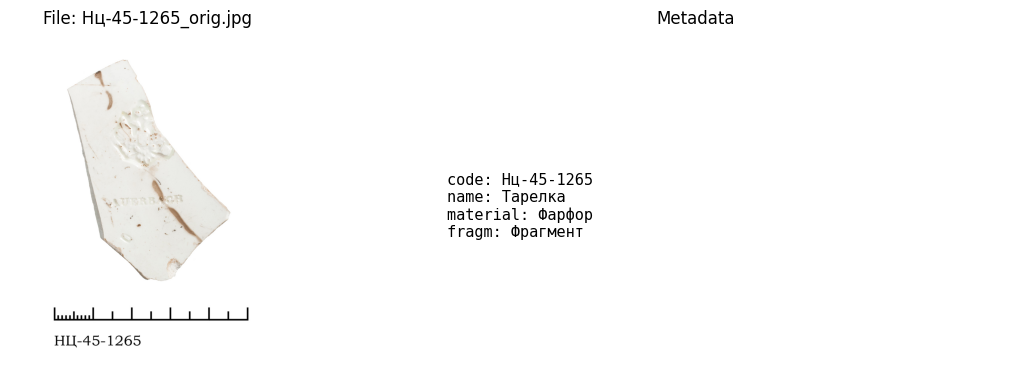

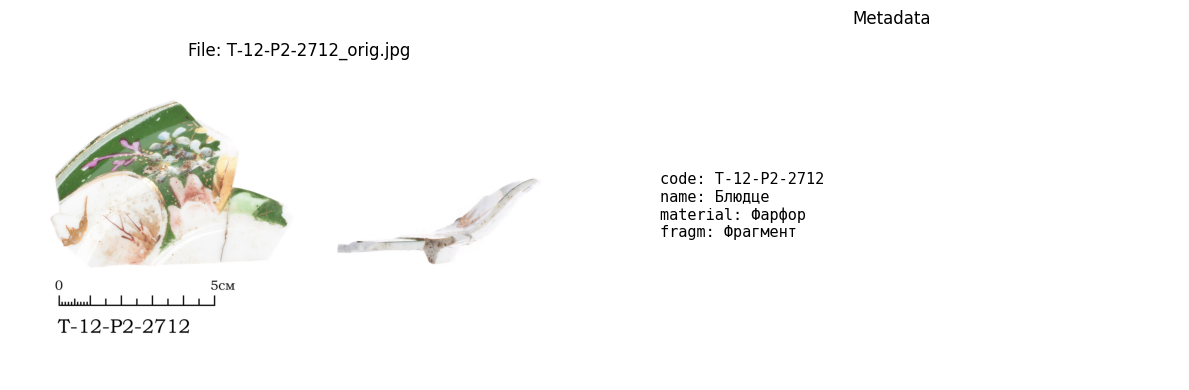

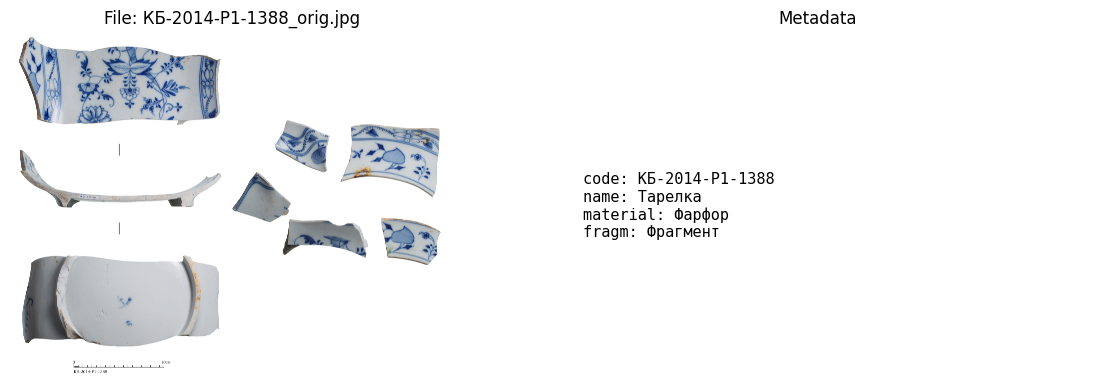

In [ ]:
# Визуализация примеров
df = df[df['is_valid']].copy()

if not df.empty:
    n_samples = 3
    samples = df.sample(n_samples, random_state=42)

    for idx, row in samples.iterrows():
        plt.figure(figsize=(12, 4))

        # Изображение
        img_path = os.path.join(cfg.images_dir, row['image_file'])
        try:
            img = Image.open(img_path)
            plt.subplot(1, 2, 1)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"File: {row['image_file']}")
        except:
            print(f"Не удалось открыть {img_path}")

        # Метаданные
        plt.subplot(1, 2, 2)
        meta_info = [f"{col}: {row[col]}" for col in ['code', 'name', 'material', 'fragm'] if col in row]
        meta_text = "\n".join(meta_info)
        plt.text(0.1, 0.5, meta_text, fontsize=11, va='center', family='monospace')
        plt.axis('off')
        plt.title("Metadata")

        plt.tight_layout()
        plt.show()

In [ ]:
# Сохранение финального маппинга
output_path = 'data/interim/inventory_mapped.csv'
df.to_csv(output_path, index=False)
print(f"Валидный датасет сохранен в: {output_path}")

Валидный датасет сохранен в: data/interim/inventory_mapped.csv


## EDA


### Распределения

Checking image sizes:   0%|          | 0/1139 [00:00<?, ?it/s]

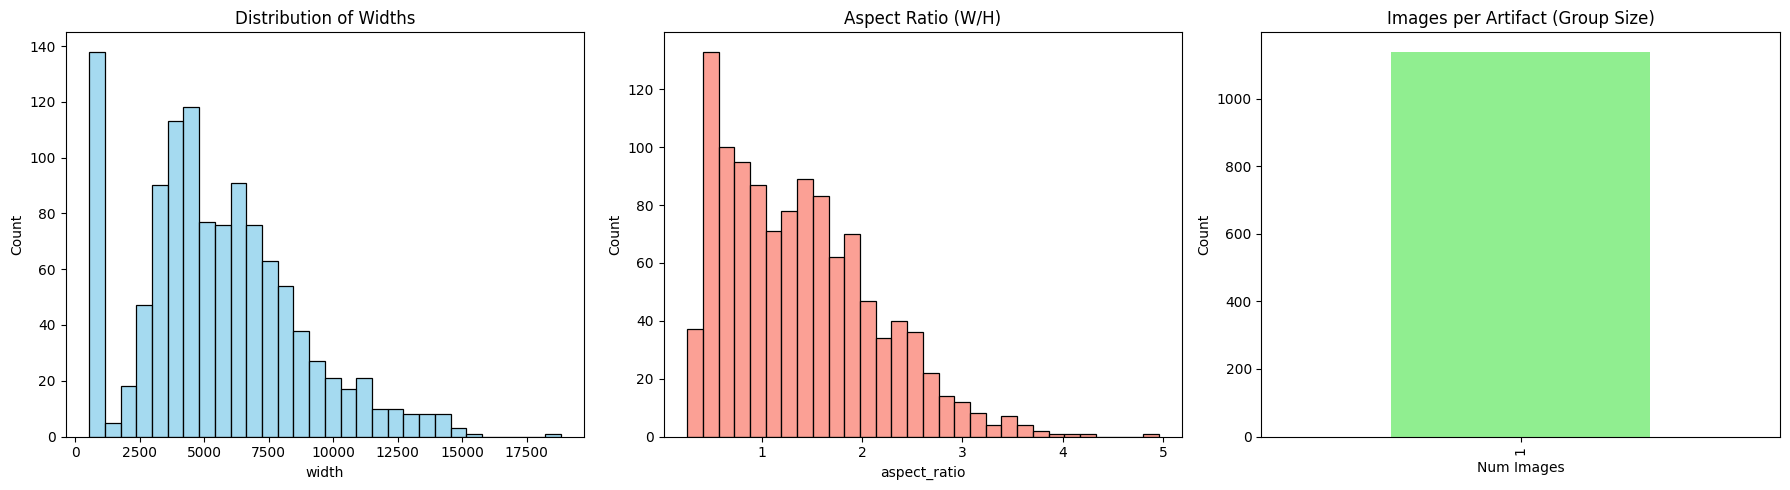

In [ ]:
df = pd.read_csv('data/interim/inventory_mapped.csv')
IMAGES_DIR = cfg.images_dir

# Сбор геометрических данных (размеры и аспекты)
# Сначала считаем геометрию в основном df
widths, heights, aspect_ratios = [], [], []
for img_name in tqdm(df['image_file'], desc="Checking image sizes"):
    with Image.open(os.path.join(IMAGES_DIR, img_name)) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h)

df['width'], df['height'], df['aspect_ratio'] = widths, heights, aspect_ratios
df = df[df['is_valid']].copy()


# Распределения
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['width'], bins=30, ax=axes[0], color='skyblue').set_title('Distribution of Widths')
sns.histplot(df['aspect_ratio'], bins=30, ax=axes[1], color='salmon').set_title('Aspect Ratio (W/H)')
df['code'].value_counts().value_counts().plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title('Images per Artifact (Group Size)')
axes[2].set_xlabel('Num Images'), axes[2].set_ylabel('Count')
plt.tight_layout()
plt.show()

### Сетка из 12 изображений

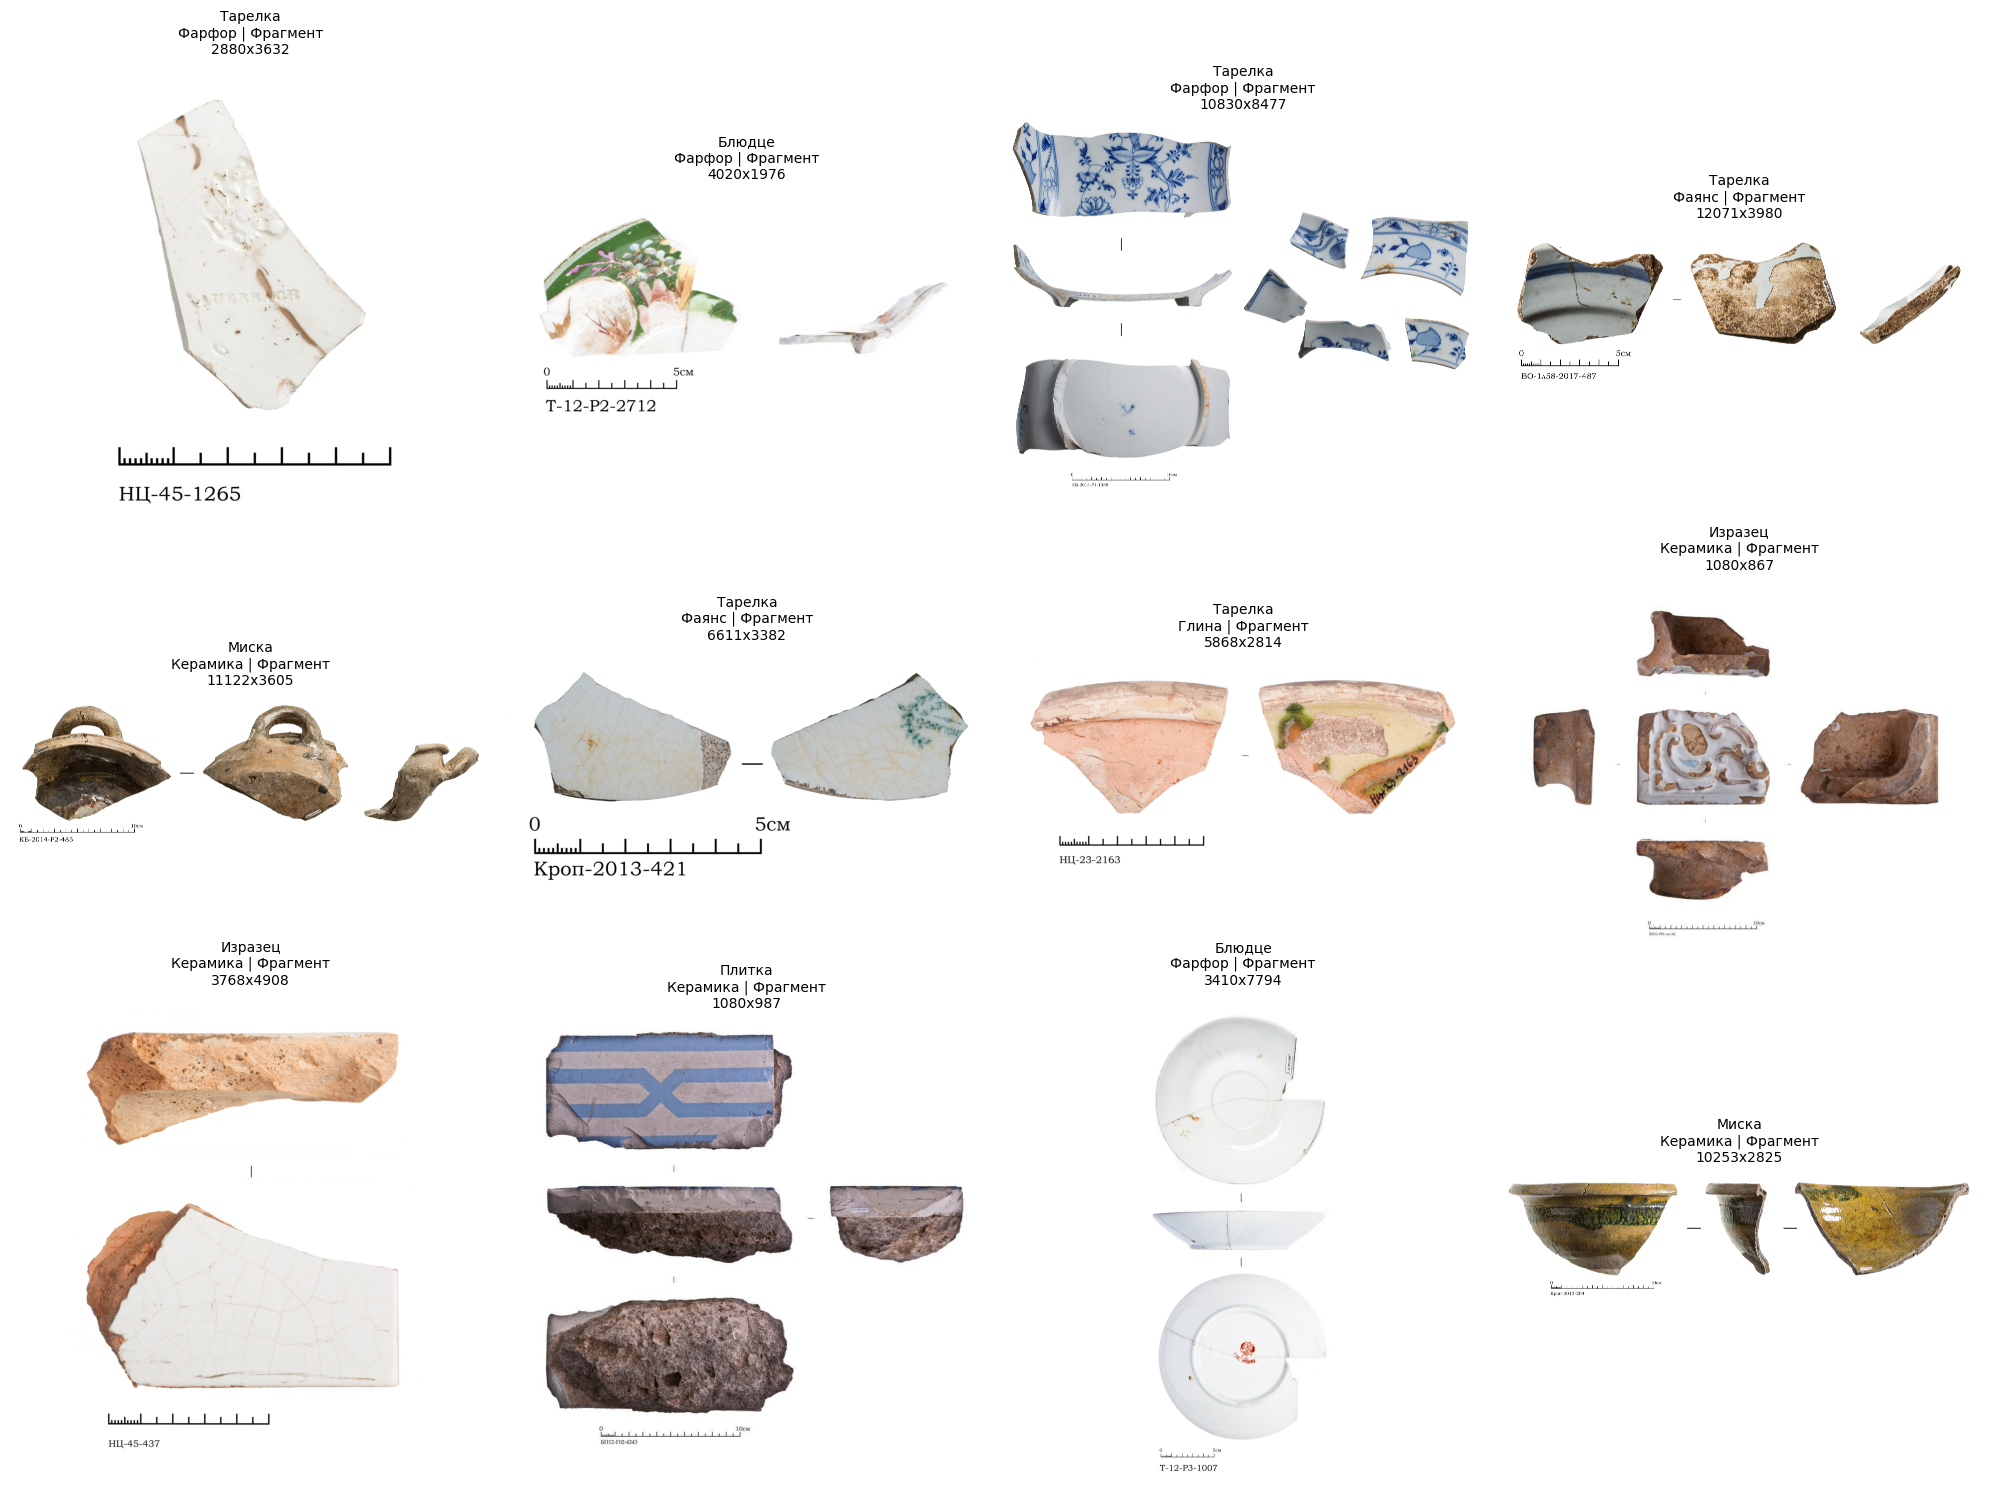

In [ ]:
def show_grid(df, n=12, cols=4):
    rows = n // cols
    plt.figure(figsize=(20, 5 * rows))
    samples = df.sample(n, random_state=42)

    for i, (_, row) in enumerate(samples.iterrows()):
        plt.subplot(rows, cols, i + 1)
        img = Image.open(os.path.join(IMAGES_DIR, row['image_file']))
        plt.imshow(img)
        # Сокращенные метаданные для подписи
        label = f"{row['name'][:20]}\n{row['material']} | {row['fragm']}\n{img.size[0]}x{img.size[1]}"
        plt.title(label, fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_grid(df)

### Эвристика и Visual Modes

In [ ]:
def advanced_visual_heuristic(img_path):
    with Image.open(img_path).convert('L') as img:
        img_np = np.array(img.resize((256, 256)))

        # Фон
        corners = [img_np[0:20, 0:20], img_np[0:20, -20:], img_np[-20:, 0:20], img_np[-20:, -20:]]
        bg_mean = np.mean(corners)
        if bg_mean > 220: bg_type = 'white'
        elif bg_mean > 150: bg_type = 'light-gray'
        else: bg_type = 'other/dark'

        # Доля предмета
        # Считаем пиксели, которые значимо отличаются от фона
        fg_mask = np.abs(img_np - bg_mean) > 30
        foreground_ratio = np.sum(fg_mask) / img_np.size

        # Поиск текста и линеек (has_overlay_text / has_scale_bar)
        import scipy.ndimage as ndimage
        grad = ndimage.gaussian_gradient_magnitude(img_np.astype(float), sigma=1)

        # Эвристика: если внизу кадра или по углам есть зоны с высокой плотностью резких линий
        bottom_strip = grad[200:, :]
        has_scale_bar = np.mean(bottom_strip) > 5
        has_overlay_text = np.max(grad) > 50

        # Режим раскладки (layout_mode)
        # Простая эвристика: если fg_ratio размазан по кадру, а не в центре
        center_mass = np.sum(fg_mask[64:192, 64:192]) / np.sum(fg_mask + 1e-6)
        if center_mass < 0.4:
            layout_mode = 'multi-view/complex'
        elif foreground_ratio < 0.1:
            layout_mode = 'close-up/macro'
        else:
            layout_mode = 'single_fragment'

    return bg_type, foreground_ratio, has_scale_bar, has_overlay_text, layout_mode

In [ ]:
# Применяем на подвыборке
subset_indices = df.sample(50, random_state=42).index
results = [advanced_visual_heuristic(os.path.join(IMAGES_DIR, df.loc[i, 'image_file'])) for i in subset_indices]

df_sub = df.loc[subset_indices].copy()
df_sub['bg_type'], df_sub['fg_ratio'], df_sub['has_scale_bar'], \
df_sub['has_overlay_text'], df_sub['layout_mode'] = zip(*results)

# ВЫВОД ДЛЯ ОТЧЕТА
print("\nВизуальный анализ (n=50)")
print(f"\nТипы фона:{df_sub['bg_type'].value_counts(normalize=True)}")
print(f"\nРежимы раскладки:{df_sub['layout_mode'].value_counts()}")
print(f"\nНаличие линейки (эвристика): {df_sub['has_scale_bar'].sum()} шт.")
print(f"\nНаличие текста/номеров: {df_sub['has_overlay_text'].sum()} шт.")
print(f"\nСредняя заполненность кадра: {df_sub['fg_ratio'].mean():.2f}")


Визуальный анализ (n=50)

Типы фона:bg_type
white         0.96
other/dark    0.04
Name: proportion, dtype: float64

Режимы раскладки:layout_mode
multi-view/complex    27
single_fragment       21
close-up/macro         2
Name: count, dtype: int64

Наличие линейки (эвристика): 13 шт.

Наличие текста/номеров: 50 шт.

Средняя заполненность кадра: 0.28


### Проблемные примеры

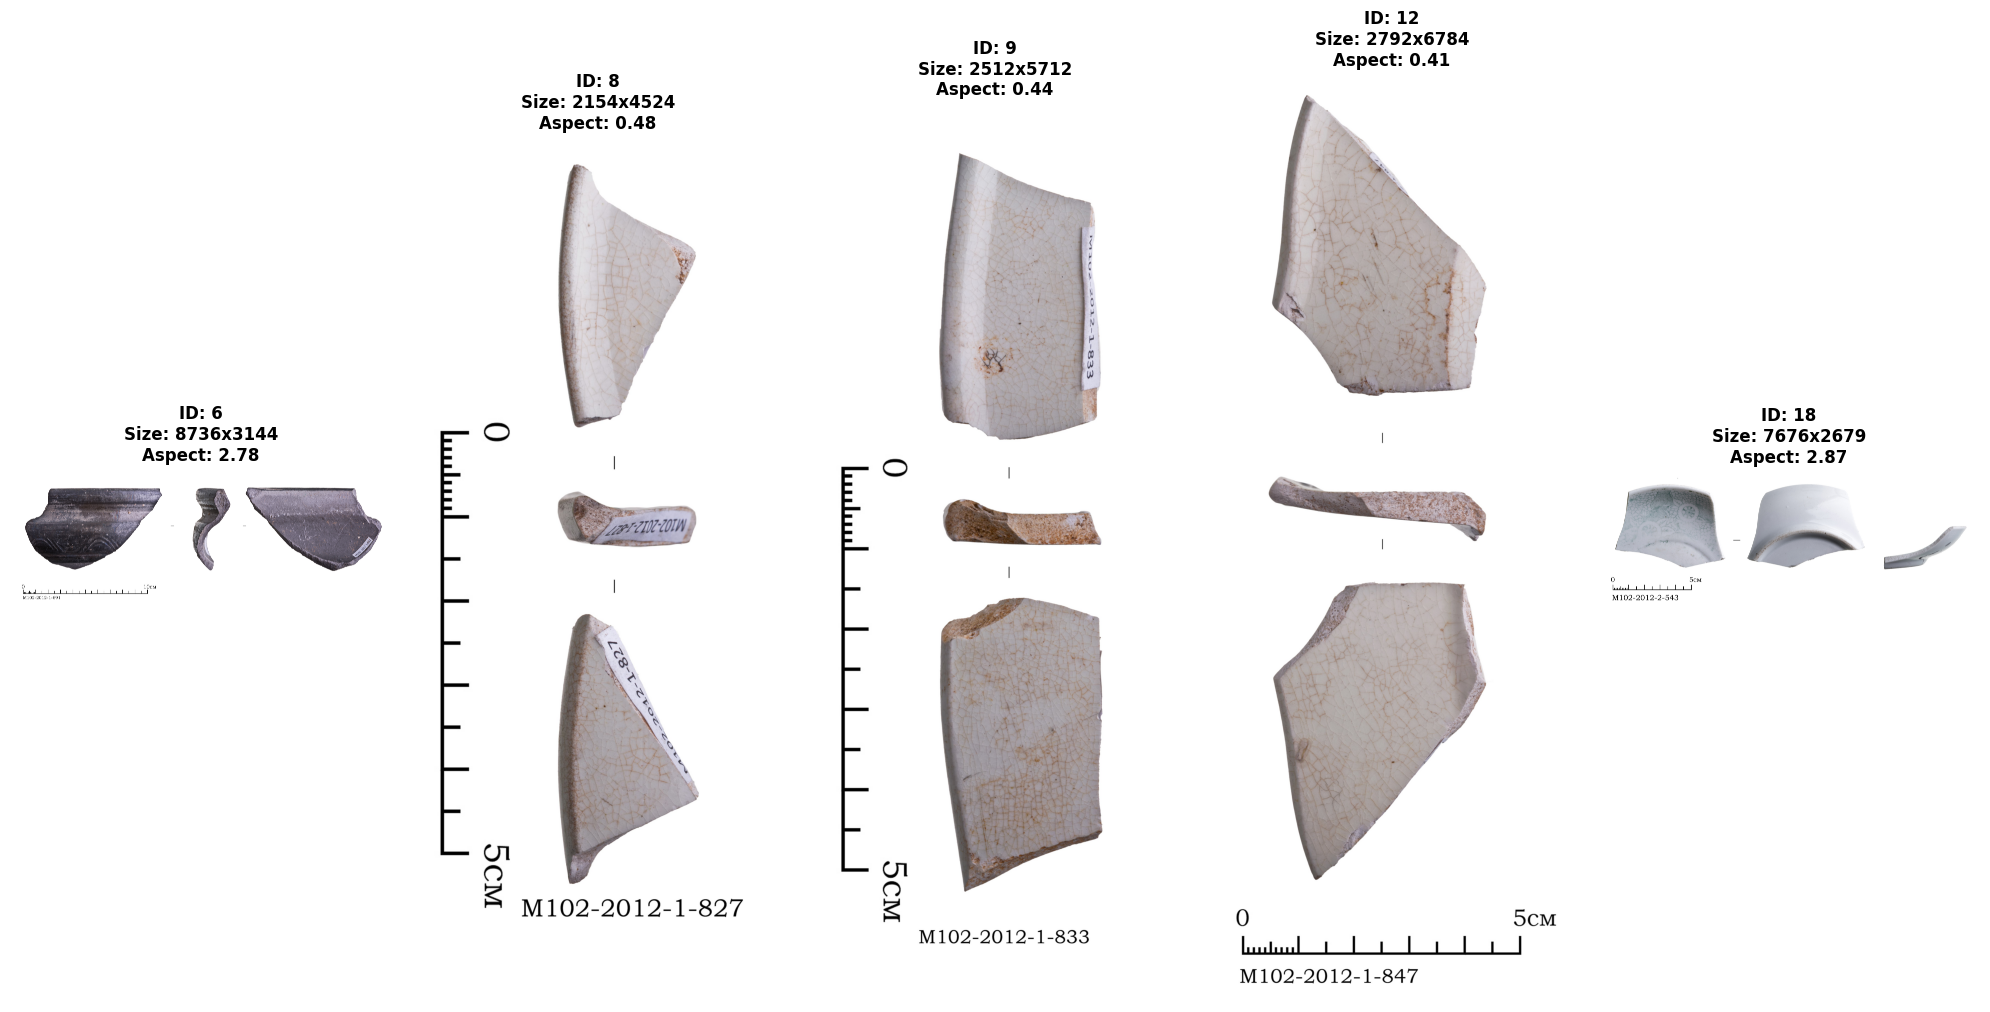

In [ ]:
problem_indices = [6, 8, 9, 12, 18]

plt.figure(figsize=(20, 10))

for i, idx in enumerate(problem_indices):
    plt.subplot(1, len(problem_indices), i + 1)

    if idx in df.index:
        row = df.loc[idx]
        img_path = os.path.join(IMAGES_DIR, row['image_file'])

        try:
            img = Image.open(img_path)
            plt.imshow(img)

            info = f"ID: {idx}\nSize: {img.size[0]}x{img.size[1]}\nAspect: {row['aspect_ratio']:.2f}"
            plt.title(info, fontsize=12, fontweight='bold')
        except Exception as e:
            plt.title(f"ID: {idx} - Error")
            print(f"Не удалось открыть изображение по индексу {idx}: {e}")
    else:
        plt.title(f"ID: {idx} - Not in df")
        plt.text(0.5, 0.5, "Index missing", ha='center')

    plt.axis('off')

plt.tight_layout()
plt.show()

Наличие ярких масштабных линеек и текстовых меток создает риск shortcut learning, где модель ориентируется на сопутствующие предметы, а не на сам артефакт. Также малый foreground_ratio для малых предметов приводит к потере детализации при стандартном ресайзе.

## Подготовка структуры

In [ ]:
# Выводим 20 примеров для анализа текстов
pd.set_option('display.max_colwidth', None)
display(df[['code', 'name', 'description', 'material', 'fragm']].sample(20, random_state=42))

,code,name,description,material,fragm
788,Нц-45-1265,Тарелка,Тарелки фарфоровой с клеймом донца фр-т,Фарфор,Фрагмент
904,Т-12-Р2-2712,Блюдце,Блюдца фарфорового профиля фр-т,Фарфор,Фрагмент
289,КБ-2014-Р1-1388,Тарелка,"Тарелки фарфоровой с синим цветочным рисунком внутри придонной части фрагмент клеймо снаружи вдавлено ""Мeissen…2 1/2"" подглазурно синим ""Meissen…39""",Фарфор,Фрагмент
1040,ВО-1л58-2017-0487,Тарелка,Тарелки фаянсовой с голубой поливой снаружи и внутри с темно-голубой полосой по краю венчика фр-т,Фаянс,Фрагмент
332,КБ-2014-Р2-0485,Миска,Миски (?) с ручкой белоглиняного с нагаром и частичной зеленой поливой снаружи и внутри профиль,Керамика,Фрагмент
109,Кроп-2013-421,Тарелка,Сосуда (тарелки ?) фаянсовой с белой поливой внутри и снаружи донца клейменого фр-т,Фаянс,Фрагмент
526,Нц-23-2163,Тарелка,Тарелки красноглиняной с зеленой и коричневой росписью по желтой поливе внутри края фр-т,Глина,Фрагмент
56,БП11-Р01-тех-0061,Изразец,Изразца светлоглиняного орнаментированного с белой поливой и полихромной росписью фр-т,Керамика,Фрагмент
752,Нц-45-0437,Изразец,Изразца красноглиняного с белой поливой фр-т,Керамика,Фрагмент
240,БП12-Г02-4243,Плитка,Плитка напольная керамическая метлахская с голубой росписью и следами раствора фрагментированная,Керамика,Фрагмент


#### Обоснование выбора полей

| field_name | Почему визуально видно | Тип цели | Классов (примерно) | Доля пропусков | Риск неоднозначности |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **`name`** | Определяется по уникальной морфологии и контурам предмета (гвоздь, изразец, сосуд). | **Single-label** | ~45 | 0% | **Средний**: мелкие фрагменты разных сосудов могут выглядеть одинаково. |
| **`material`** | Виден через текстуру поверхности, цвет, блеск и характер сколов/коррозии. | **Single-label** | ~10 | 0% | **Низкий**: керамика, металл и стекло имеют контрастные визуальные признаки. |
| **`fragm`** | Визуально фиксируется по наличию сломов, отсутствию частей формы или полноте объекта. | **Single-label** | 3-5 | 0% | **Низкий**: грань между «целым» и «фрагментом» обычно очевидна. |


### Поля, которые мы НЕ берем в Baseline

* **`cultlayer` (Культурный слой):**  По фотографии невозможно определить, в каком слое лежал предмет. Это внешний контекст.
* **`survyear` (Год находки):** Это административная дата. На самом артефакте она никак не отражена.
* **`description` (Полное описание):** Это не поле, а неструктурированный текст. Использовать его как цель для классификации нельзя.
* **`size` (Размер):** Мы не берем его в Baseline, так как без детекции линейки и калибровки камеры нейросеть не может отличить маленький гвоздь на макро-фото от большого гвоздя, снятого издалека.

In [ ]:
selected_fields = ['name', 'material', 'fragm']

print("Анализ выбранных полей")
for field in selected_fields:
    unique_vals = df[field].unique()
    print(f"\nПоле: {field}")
    print(f"Уникальных значений: {len(unique_vals)}")
    print(f"Примеры: {unique_vals[:10]}")

    # Считаем долю пропусков
    missing = df[field].isna().mean() * 100
    print(f"Доля пропусков: {missing:.2f}%")

Анализ выбранных полей

Поле: name
Уникальных значений: 9
Примеры: ['Изразец' 'Тарелка' 'Миска' 'Блюдце' 'Плитка' 'Крышка' 'Миска (?)'
 'Игрушка' 'Тарелка/блюдо']
Доля пропусков: 0.00%

Поле: material
Уникальных значений: 19
Примеры: ['Керамика' 'Фаянс' 'Фарфор' 'Каменная масса' 'Стекло' 'Белый металл'
 'Основание - бетон, покрытие - композитный материал'
 'Белоглиняная керамика' 'Красноглиняная керамика' 'Серолощеная керамика']
Доля пропусков: 0.00%

Поле: fragm
Уникальных значений: 2
Примеры: ['Фрагмент' 'Целый']
Доля пропусков: 0.00%


## Нормализация словарей

In [ ]:
def normalize_text(text):
    if pd.isna(text): return "unknown"
    text = str(text).lower().strip()
    # Убираем точки и лишние сокращения для базового сравнения
    text = text.replace("фр-т", "фрагмент").replace(" ф-т", " фрагмент")
    return text

# Применяем базовую чистку
df['name_norm'] = df['name'].apply(normalize_text)
df['material_norm'] = df['material'].apply(normalize_text)

# 2. Создаем словарь синонимов и опечаток
name_mapping = {
    "изразца": "изразец",
    "изразца фрагмент": "изразец",
    "фр-т изразца": "изразец",
    "гвоздя": "гвоздь",
    "гвоздя фрагмент": "гвоздь",
    "сосуда": "сосуд",
    "фрагмент сосуда": "сосуд",
    "стенка сосуда": "сосуд"
}

material_mapping = {
    "керамика.": "керамика",
    "чернолощеная керамика": "керамика",
    "белоглиняная керамика": "керамика",
    "железо": "металл",
    "цветной металл": "металл"
}

# Применяем маппинг
df['name_norm'] = df['name_norm'].replace(name_mapping)
df['material_norm'] = df['material_norm'].replace(material_mapping)

In [ ]:
def finalize_labels(df, col, min_samples=5):
    # Помечаем пропуски
    df[f'{col}_is_missing'] = df[col].isna()

    # Кодируем редкие категории как 'other'
    counts = df[f'{col}_norm'].value_counts()
    rare_classes = counts[counts < min_samples].index

    df[f'{col}_final'] = df[f'{col}_norm'].replace(rare_classes, 'other')

    # Помечаем неоднозначность (uncertain)
    # В археологии это часто слова со знаком вопроса или 'неопред.'
    df[f'{col}_is_uncertain'] = df[col].astype(str).str.contains(r'\?', na=False)

    return df

for col in ['name', 'material']:
    df = finalize_labels(df, col)

# Для fragm (там мало классов, просто чистим)
df['fragm_final'] = df['fragm'].apply(normalize_text).replace({'фрагмент': 'fragment', 'целое': 'whole'})

In [ ]:
print("Распределение TOP-10 классов (Name)")
print(df['name_final'].value_counts().head(10))

print("\nСтатистика пропусков и редких значений")
print(f"Заменено на 'other' (Name): {len(df[df['name_final'] == 'other'])}")
print(f"Выявлено неоднозначных записей (?): {df['name_is_uncertain'].sum()}")

Распределение TOP-10 классов (Name)
name_final
тарелка    376
изразец    349
блюдце     158
крышка     119
миска      100
плитка      24
other        8
игрушка      5
Name: count, dtype: int64

Статистика пропусков и редких значений
Заменено на 'other' (Name): 8
Выявлено неоднозначных записей (?): 4


In [ ]:
def auto_description_engine(preds, confs, thresholds={'high': 0.85, 'med': 0.6}):
    """
    Генератор описания на основе предсказаний мультитаск-модели.

    Args:
        preds: словарь с предсказанными метками категорий
        confs: словарь с уверенностью модели (0.0 - 1.0) для каждой категории
    """
    parts = []

    # ТИП ПРЕДМЕТА
    name_val = preds.get('name', 'артефакт').lower()
    name_p = confs.get('name', 0)

    if name_p > thresholds['high']:
        parts.append(name_val.capitalize())
    elif name_p > thresholds['med']:
        parts.append(f"Предположительно {name_val}")
    else:
        # Если уверенность совсем низкая, используем максимально грубое определение
        parts.append("Неопределенный артефакт")

    #  МАТЕРИАЛ
    mat_val = preds.get('material', '').lower()
    mat_p = confs.get('material', 0)

    if mat_p > thresholds['high']:
        parts.append(f"из материала: {mat_val}")
    elif mat_p > thresholds['med']:
        parts.append(f"(возм. {mat_val})")
    # При p < thresholds['med'] материал просто не упоминается

    # ЦЕЛОСТНОСТЬ
    frag_val = preds.get('fragm', '').lower()
    frag_p = confs.get('fragm', 0)

    # Для целостности берем только высокую уверенность, чтобы не гадать
    if frag_p > thresholds['high']:
        if 'фрагмент' in frag_val or 'fragment' in frag_val:
            parts.append(", в состоянии фрагмента")
        elif 'целое' in frag_val or 'whole' in frag_val:
            parts.append(", целой сохранности")

    # Сборка строки
    res = " ".join(parts).replace(" ,", ",")
    return res.strip() + "."

In [ ]:
test_scenarios = [
    {
        "desc": "Идеальное предсказание (High Confidence)",
        "preds": {"name": "изразец", "material": "керамика", "fragm": "фрагмент"},
        "confs": {"name": 0.98, "material": 0.95, "fragm": 0.92}
    },
    {
        "desc": "Сомнение в типе предмета (Medium Confidence)",
        "preds": {"name": "гвоздь", "material": "металл", "fragm": "целое"},
        "confs": {"name": 0.65, "material": 0.91, "fragm": 0.88}
    },
    {
        "desc": "Низкая уверенность в материале (Пропуск поля)",
        "preds": {"name": "сосуд", "material": "стекло", "fragm": "фрагмент"},
        "confs": {"name": 0.96, "material": 0.35, "fragm": 0.90}
    },
    {
        "desc": "Слабая уверенность во всём (Fallback)",
        "preds": {"name": "монета", "material": "металл", "fragm": "целое"},
        "confs": {"name": 0.45, "material": 0.40, "fragm": 0.30}
    },
    {
        "desc": "Средняя уверенность в материале (Маркер 'возм.')",
        "preds": {"name": "бусина", "material": "янтарь", "fragm": "целое"},
        "confs": {"name": 0.92, "material": 0.70, "fragm": 0.89}
    }
]


for ts in test_scenarios:
    result = auto_description_engine(ts['preds'], ts['confs'])
    print(f"{ts['desc']:<40} | {result}")

Идеальное предсказание (High Confidence) | Изразец из материала: керамика, в состоянии фрагмента.
Сомнение в типе предмета (Medium Confidence) | Предположительно гвоздь из материала: металл, целой сохранности.
Низкая уверенность в материале (Пропуск поля) | Сосуд, в состоянии фрагмента.
Слабая уверенность во всём (Fallback)    | Неопределенный артефакт.
Средняя уверенность в материале (Маркер 'возм.') | Бусина (возм. янтарь), целой сохранности.


## Подготовка данных

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss_test = GroupShuffleSplit(n_splits=1, train_size=0.85, random_state=42)
train_val_idx, test_open_idx = next(gss_test.split(df, groups=df['code']))

df_train_val = df.iloc[train_val_idx].reset_index(drop=True)
df_test = df.iloc[test_open_idx].reset_index(drop=True)

gss_val = GroupShuffleSplit(n_splits=1, train_size=0.824, random_state=42)
train_idx, val_idx = next(gss_val.split(df_train_val, groups=df_train_val['code']))

df_train = df_train_val.iloc[train_idx].reset_index(drop=True)
df_val = df_train_val.iloc[val_idx].reset_index(drop=True)

print(f"Размер train_inner: {len(df_train)}")
print(f"Размер val_inner: {len(df_val)}")
print(f"Размер test_open: {len(df_test)}")

Размер train_inner: 797
Размер val_inner: 171
Размер test_open: 171


#### Размеры сабсетов и проверка пересечения групп

In [ ]:
def check_splits(train, val, test):
    print(f"Размеры сплитов")
    print(f"Train: {len(train)} строк")
    print(f"Val:   {len(val)} строк")
    print(f"Test:  {len(test)} строк")

    # Проверка пересечения групп (artifact_id / code)
    set_train = set(train['code'])
    set_val = set(val['code'])
    set_test = set(test['code'])

    inter_train_val = set_train.intersection(set_val)
    inter_val_test = set_val.intersection(set_test)
    inter_train_test = set_train.intersection(set_test)

    print(f"\nПроверка утечек (пересечение групп)")
    print(f"Пересечение Train/Val: {len(inter_train_val)} групп")
    print(f"Пересечение Val/Test:   {len(inter_val_test)} групп")
    print(f"Пересечение Train/Test: {len(inter_train_test)} групп")

    if len(inter_train_val) + len(inter_val_test) + len(inter_train_test) == 0:
        print("Утечек по группам не обнаружено.")
    else:
        print(" Обнаружены общие группы в разных сплитах!")

check_splits(df_train, df_val, df_test)

Размеры сплитов
Train: 797 строк
Val:   171 строк
Test:  171 строк

Проверка утечек (пересечение групп)
Пересечение Train/Val: 0 групп
Пересечение Val/Test:   0 групп
Пересечение Train/Test: 0 групп
Утечек по группам не обнаружено.


#### Распределение классов по сплитам

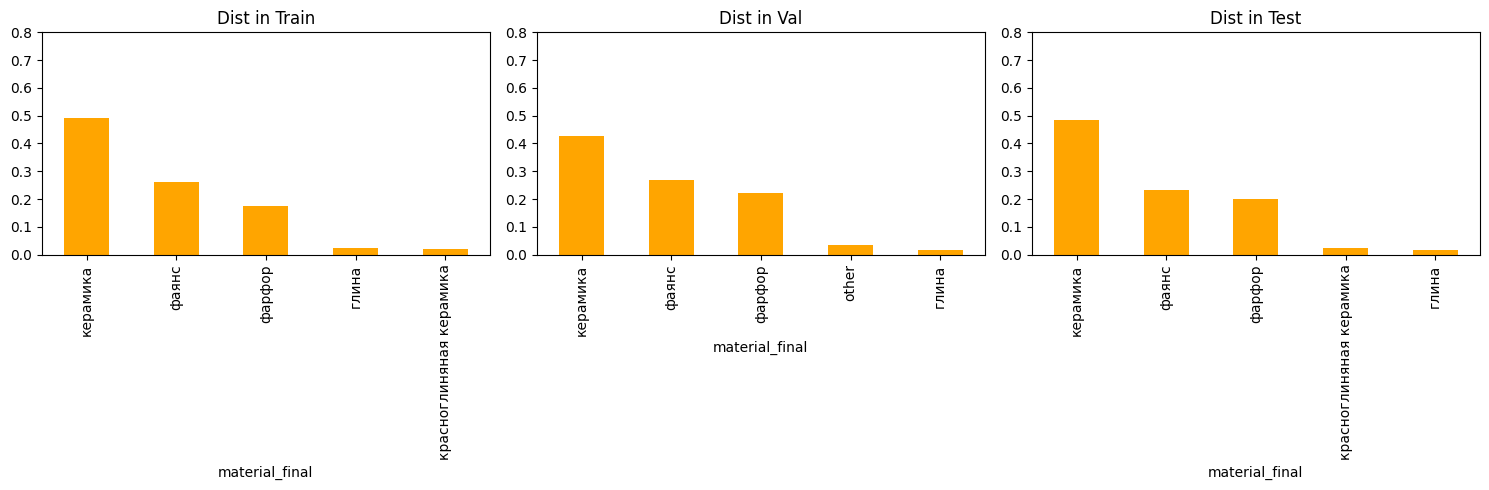

In [ ]:
plt.figure(figsize=(15, 5))
target_col = 'material_final'

for i, (name, d) in enumerate([('Train', df_train), ('Val', df_val), ('Test', df_test)]):
    plt.subplot(1, 3, i+1)
    d[target_col].value_counts(normalize=True).head(5).plot(kind='bar', color='orange')
    plt.title(f"Dist in {name}")
    plt.ylim(0, 0.8)
plt.tight_layout()
plt.show()

 #### Image preprocessing и аугментации

In [ ]:
SIZE = 448

# Пайплайн для тренировки
train_transform = A.Compose([
    # Геометрия
    A.LongestMaxSize(max_size=SIZE),
    A.PadIfNeeded(min_height=SIZE, min_width=SIZE, border_mode=cv2.BORDER_CONSTANT, fill=0),

    # Аугментации
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.Affine(
        translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
        scale=(0.95, 1.05),
        rotate=(-15, 15),
        interpolation=cv2.INTER_LINEAR,
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        p=0.5
    ),

    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),

    # Нормализация
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Пайплайн для валидации
val_transform = A.Compose([
    A.LongestMaxSize(max_size=SIZE),
    A.PadIfNeeded(min_height=SIZE, min_width=SIZE, border_mode=cv2.BORDER_CONSTANT, fill=0),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

Проверка Train Аугментаций


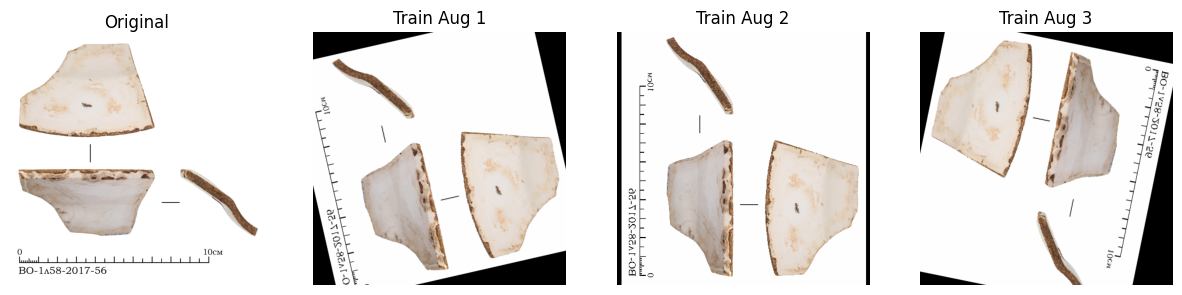

Проверка Val Трансформаций (Чистый Resize+Pad)


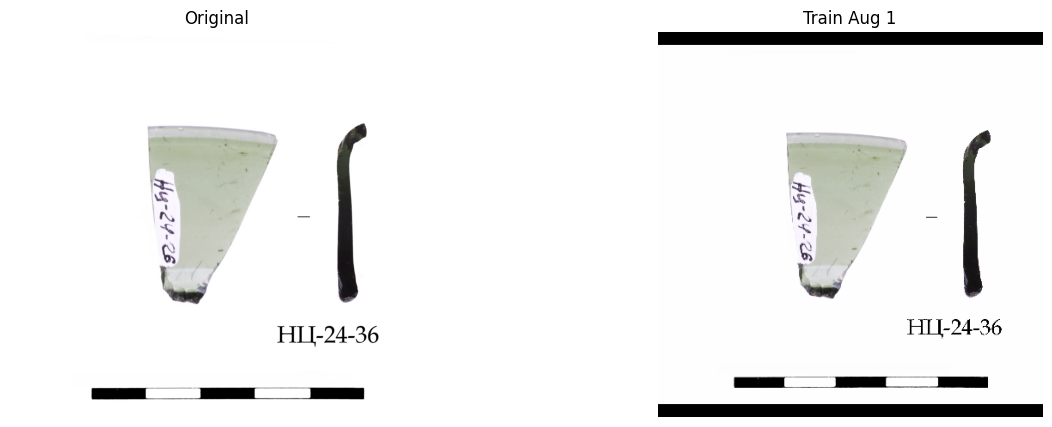

In [ ]:
def visualize_augmentations(df, transform, n=3):
    sample = df.sample(1).iloc[0]
    img_path = os.path.join(IMAGES_DIR, sample['image_file'])
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 5))

    # Оригинал
    plt.subplot(1, n+1, 1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis('off')

    # Аугментированные версии
    for i in range(n):
        augmented = transform(image=image)['image']
        # Инвертируем нормализацию для корректного отображения
        aug_img = augmented.permute(1, 2, 0).numpy()
        aug_img = (aug_img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
        aug_img = np.clip(aug_img, 0, 1)

        plt.subplot(1, n+1, i+2)
        plt.imshow(aug_img)
        plt.title(f"Train Aug {i+1}")
        plt.axis('off')
    plt.show()

# Демонстрация
print("Проверка Train Аугментаций")
visualize_augmentations(df_train, train_transform)

print("Проверка Val Трансформаций (Чистый Resize+Pad)")
visualize_augmentations(df_val, val_transform, n=1)

Риск Hue/Saturation: Я ограничил изменение цвета. В археологии цвет прямой признак материала. Агрессивный сдвиг фаз убьет этот сигнал.

Почему Pad вместо Crop: На многих фото предмет занимает малую часть кадра. Агрессивный RandomResizedCrop может вырезать только кусок фона или только линейку, полностью удалив артефакт из обучения. Pad гарантирует, что предмет всегда в кадре целиком.

#### Подготовка Dataset + DataLoader

In [ ]:
# Создаем словарь для хранения энкодеров по каждому полю
le_dict = {}
target_cols = ['name_final', 'material_final', 'fragm_final']

for col in target_cols:
    le = LabelEncoder()

    # Обучаем СТРОГО на получившейся обучающей выборке (train_inner)
    train_values = df_train[col].astype(str).unique().tolist()

    if 'unknown' not in train_values:
        train_values.append('unknown')

    le.fit(train_values)
    le_dict[col] = le

    # Безопасно кодируем все три датафрейма.
    # Если в val или test_open будет редкий класс, коего нет в трейне, он станет 'unknown'
    df_train[col + '_encoded'] = le.transform(df_train[col].astype(str))

    df_val[col + '_encoded'] = df_val[col].astype(str).apply(lambda x: x if x in le.classes_ else 'unknown')
    df_val[col + '_encoded'] = le.transform(df_val[col + '_encoded'])

    df_test[col + '_encoded'] = df_test[col].astype(str).apply(lambda x: x if x in le.classes_ else 'unknown')
    df_test[col + '_encoded'] = le.transform(df_test[col + '_encoded'])

    print(f"Энкодер для {col} готов. Классов: {len(le.classes_)}")


class SimilisDataset(Dataset):
    def __init__(self, df, image_dir, transform=None, label_encoders=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.label_encoders = label_encoders

        # Определяем целевые колонки
        self.target_cols = ['name_final', 'material_final', 'fragm_final']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Загрузка изображения
        img_path = os.path.join(self.image_dir, row['image_file'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Аугментации
        if self.transform:
            image = self.transform(image=image)['image']

        # Подготовка таргетов и масок
        targets = {}
        target_masks = {}

        for col in self.target_cols:
            val = row[col]
            # Если значение было помечено как unknown
            if val == 'unknown' or pd.isna(val):
                targets[col] = torch.tensor(0, dtype=torch.long)
                target_masks[col] = torch.tensor(0.0, dtype=torch.float32)
            else:
                # Маппинг строки в индекс
                idx_val = self.label_encoders[col].transform([val])[0]
                targets[col] = torch.tensor(idx_val, dtype=torch.long)
                target_masks[col] = torch.tensor(1.0, dtype=torch.float32)

        # Метаданные
        metadata = {
            'image_file': row['image_file'],
            'group_key': str(row['code'])
        }

        return {
            'image': image,
            'targets': targets,
            'target_masks': target_masks,
            'metadata': metadata
        }

Энкодер для name_final готов. Классов: 9
Энкодер для material_final готов. Классов: 9
Энкодер для fragm_final готов. Классов: 3


In [ ]:
# Сборка лоадеров
train_dataset = SimilisDataset(df_train, IMAGES_DIR, transform=train_transform, label_encoders=le_dict)
val_dataset = SimilisDataset(df_val, IMAGES_DIR, transform=val_transform, label_encoders=le_dict)
test_dataset = SimilisDataset(df_test, IMAGES_DIR, transform=val_transform, label_encoders=le_dict)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
batch = next(iter(train_loader))

print(f"Image shape: {batch['image'].shape}")
print(f"Image dtype: {batch['image'].dtype}")
print(f"Target 'name' shape: {batch['targets']['name_final'].shape}")
print(f"Target 'name' dtype: {batch['targets']['name_final'].dtype}")

Image shape: torch.Size([16, 3, 448, 448])
Image dtype: torch.float32
Target 'name' shape: torch.Size([16])
Target 'name' dtype: torch.int64


Sanity Check для элемента #5
Файл: М102-2012-2-1360_orig.jpg
Группа (code): М102-2012-2-1360
Декодированные метки: {'name_final': np.str_('тарелка'), 'material_final': np.str_('фаянс'), 'fragm_final': np.str_('fragment')}
Auto-Description: Тарелка из материала: фаянс, в состоянии фрагмента.


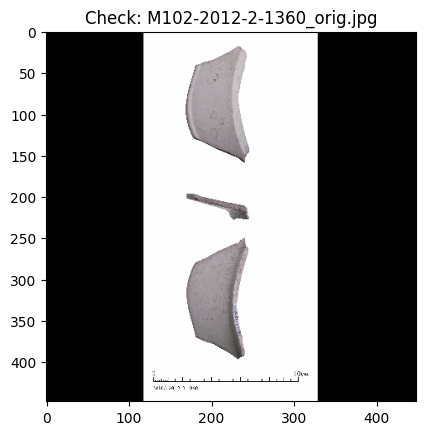

In [ ]:
def run_sanity_check(dataset, idx=0):
    print(f"Sanity Check для элемента #{idx}")
    item = dataset[idx]

    # Проверка пути и картинки
    print(f"Файл: {item['metadata']['image_file']}")
    print(f"Группа (code): {item['metadata']['group_key']}")

    # Декодирование меток обратно в текст
    decoded_labels = {}
    for col in ['name_final', 'material_final', 'fragm_final']:
        idx_val = item['targets'][col].item()
        label = le_dict[col].inverse_transform([idx_val])[0]
        mask = item['target_masks'][col].item()
        decoded_labels[col] = label if mask > 0 else "MISSING"

    print(f"Декодированные метки: {decoded_labels}")

    # Проверка работы auto_description
    fake_confs = {k.split('_')[0]: 1.0 for k in decoded_labels.keys()}
    fake_preds = {k.split('_')[0]: v for k, v in decoded_labels.items()}

    description = auto_description_engine(fake_preds, fake_confs)
    print(f"Auto-Description: {description}")

    img_display = item['image'].permute(1, 2, 0).numpy()
    # Денормализация для вывода
    img_display = (img_display * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    plt.imshow(np.clip(img_display, 0, 1))
    plt.title(f"Check: {item['metadata']['image_file']}")
    plt.show()

run_sanity_check(val_dataset, idx=5)

# Часть 2

## Модель

In [ ]:
class SimilisMultiTaskModel(nn.Module):
    def __init__(self, num_classes_dict, backbone_name='resnet50', pretrained=True):
        super(SimilisMultiTaskModel, self).__init__()

        # Загружаем ResNet50
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0)

        # Определяем размер эмбеддинга
        self.num_features = self.backbone.num_features

        # Создаем отдельные классификационные "головы" для каждого поля
        self.heads = nn.ModuleDict({
            'name': nn.Linear(self.num_features, num_classes_dict['name_final']),
            'material': nn.Linear(self.num_features, num_classes_dict['material_final']),
            'fragm': nn.Linear(self.num_features, num_classes_dict['fragm_final'])
        })

    def forward(self, x):
        # x: (B, 3, 448, 448)

        # Извлекаем визуальный эмбеддинг
        embedding = self.backbone(x) # (B, 2048)

        logits = {
            'name': self.heads['name'](embedding),         # (B, C_name)
            'material': self.heads['material'](embedding), # (B, C_material)
            'fragm': self.heads['fragm'](embedding)        # (B, C_fragm)
        }

        return logits

# Подготовка словаря количества классов из наших LabelEncoders
num_classes_dict = {
    'name_final': len(le_dict['name_final'].classes_),
    'material_final': len(le_dict['material_final'].classes_),
    'fragm_final': len(le_dict['fragm_final'].classes_)
}

model = SimilisMultiTaskModel(num_classes_dict)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Параметры модели")
print(f"Backbone: ResNet50")
print(f"Общее число обучаемых параметров: {count_parameters(model):,}")

print(f"\nРазмеры выходов (Output Logits)")
for task, num in num_classes_dict.items():
    print(f"{task}_logits: (B, {num})")

Параметры модели
Backbone: ResNet50
Общее число обучаемых параметров: 23,551,061

Размеры выходов (Output Logits)
name_final_logits: (B, 9)
material_final_logits: (B, 9)
fragm_final_logits: (B, 3)


In [ ]:
# Берем один батч из нашего DataLoader
batch = next(iter(train_loader))
images = batch['image'] # (B, 3, 448, 448)

# Переводим модель в режим оценки для теста
model.eval()
with torch.no_grad():
    outputs = model(images)

print("\nПроверка Forward Pass")
for task, logits in outputs.items():
    print(f"Задана {task:10}: получены логиты формы {tuple(logits.shape)}")

# Финальное подтверждение
if all(outputs[t].shape[0] == images.shape[0] for t in outputs):
    print("\n[OK] Forward pass прошел успешно. Размерности батча совпадают!")


Проверка Forward Pass
Задана name      : получены логиты формы (16, 9)
Задана material  : получены логиты формы (16, 9)
Задана fragm     : получены логиты формы (16, 3)

[OK] Forward pass прошел успешно. Размерности батча совпадают!


In [ ]:
def compute_batch_metrics(logits_dict, targets_dict, masks_dict):
    total_loss = 0
    results = {}

    for task in logits_dict.keys():
        target_key = f"{task}_final"
        logits = logits_dict[task]
        target = targets_dict[target_key]
        mask = masks_dict[target_key]

        # Считаем CrossEntropy (reduction='none' чтобы применить маску)
        raw_loss = F.cross_entropy(logits, target, reduction='none')

        # Применяем маску
        masked_loss = raw_loss * mask

        # Усредняем только по валидным примерам в батче
        num_valid = mask.sum()
        task_loss = masked_loss.sum() / (num_valid + 1e-8)

        total_loss += task_loss

        # Считаем Accuracy (только для маскированных элементов)
        preds = torch.argmax(logits, dim=1)
        correct = (preds == target).float() * mask
        task_acc = correct.sum() / (num_valid + 1e-8)

        results[task] = {
            'loss': task_loss.item(),
            'acc': task_acc.item(),
            'preds': preds.cpu().numpy(),
            'gt': target.cpu().numpy(),
            'mask': mask.cpu().numpy()
        }

    return total_loss, results

# Берем один batch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
batch = next(iter(train_loader))

# Прогоняем через модель
model.eval() # Режим оценки для теста
with torch.no_grad():
    images = batch['image'].to(device)
    targets = {k: v.to(device) for k, v in batch['targets'].items()}
    masks = {k: v.to(device) for k, v in batch['target_masks'].items()}

    logits_dict = model(images)

# Считаем лосс и метрики
total_loss, metrics = compute_batch_metrics(logits_dict, targets, masks)

In [ ]:
print(f"Shapes Check")
for task in logits_dict.keys():
    t_key = f"{task}_final"
    print(f"Поле {task:8} | Logits: {logits_dict[task].shape} | GT: {targets[t_key].shape}")

print(f"\nLoss & Accuracy per Task")
print(f"Общий Loss: {total_loss.item():.4f}")
for task, res in metrics.items():
    print(f"Task {task:8} | Loss: {res['loss']:.4f} | Batch-Acc: {res['acc']:.2%}")

print(f"\nPred vs GT (первые 10 элементов)")
for task in ['name', 'material']:
    print(f"\nПоле: {task.upper()}")
    # Декодируем индексы обратно в текст для наглядности
    p_text = le_dict[f'{task}_final'].inverse_transform(metrics[task]['preds'][:10])
    g_text = le_dict[f'{task}_final'].inverse_transform(metrics[task]['gt'][:10])
    m_val = metrics[task]['mask'][:10]

    for i in range(10):
        m_str = "[VALID]" if m_val[i] > 0 else "[MASKED/IGNORED]"
        print(f"ID {i}: Pred: {p_text[i]:15} | GT: {g_text[i]:15} {m_str}")

Shapes Check
Поле name     | Logits: torch.Size([16, 9]) | GT: torch.Size([16])
Поле material | Logits: torch.Size([16, 9]) | GT: torch.Size([16])
Поле fragm    | Logits: torch.Size([16, 3]) | GT: torch.Size([16])

Loss & Accuracy per Task
Общий Loss: 5.4782
Task name     | Loss: 2.1914 | Batch-Acc: 18.75%
Task material | Loss: 2.1971 | Batch-Acc: 0.00%
Task fragm    | Loss: 1.0897 | Batch-Acc: 37.50%

Pred vs GT (первые 10 элементов)

Поле: NAME
ID 0: Pred: тарелка         | GT: тарелка         [VALID]
ID 1: Pred: игрушка         | GT: тарелка         [VALID]
ID 2: Pred: тарелка         | GT: тарелка         [VALID]
ID 3: Pred: тарелка         | GT: изразец         [VALID]
ID 4: Pred: тарелка         | GT: изразец         [VALID]
ID 5: Pred: тарелка         | GT: миска           [VALID]
ID 6: Pred: тарелка         | GT: изразец         [VALID]
ID 7: Pred: плитка          | GT: миска           [VALID]
ID 8: Pred: тарелка         | GT: изразец         [VALID]
ID 9: Pred: игрушка        

## tiny-overfit test

In [ ]:
tiny_indices = list(range(32))
tiny_subset = torch.utils.data.Subset(train_dataset, tiny_indices)

# отключаем аугментации для оверфита
tiny_subset.dataset.transform = val_transform

tiny_loader = DataLoader(tiny_subset, batch_size=16, shuffle=False)

print(f"Размер tiny-subset: {len(tiny_subset)} изображений")

Размер tiny-subset: 32 изображений


In [ ]:
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
history = {'loss': [], 'acc_name': [], 'acc_material': []}

epochs = 50

# Внешний прогресс-бар для эпох
pbar_epochs = tqdm(range(epochs), desc="Overfit Training")

for epoch in pbar_epochs:
    model.train()
    epoch_loss = 0
    correct_name = 0
    correct_mat = 0

    for batch in tiny_loader:
        images = batch['image'].to(device)
        targets = {k: v.to(device) for k, v in batch['targets'].items()}
        masks = {k: v.to(device) for k, v in batch['target_masks'].items()}

        optimizer.zero_grad()
        logits = model(images)

        loss, metrics = compute_batch_metrics(logits, targets, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Считаем точность
        with torch.no_grad():
            correct_name += (torch.argmax(logits['name'], dim=1) == targets['name_final']).float().sum().item()
            correct_mat += (torch.argmax(logits['material'], dim=1) == targets['material_final']).float().sum().item()

    current_loss = epoch_loss / len(tiny_loader)
    current_acc_n = correct_name / len(tiny_subset)
    current_acc_m = correct_mat / len(tiny_subset)

    history['loss'].append(current_loss)
    history['acc_name'].append(current_acc_n)
    history['acc_material'].append(current_acc_m)

    pbar_epochs.set_postfix({
        'loss': f"{current_loss:.4f}",
        'acc_name': f"{current_acc_n:.2%}",
        'acc_mat': f"{current_acc_m:.2%}"
    })

Overfit Training:   0%|          | 0/50 [00:00<?, ?it/s]

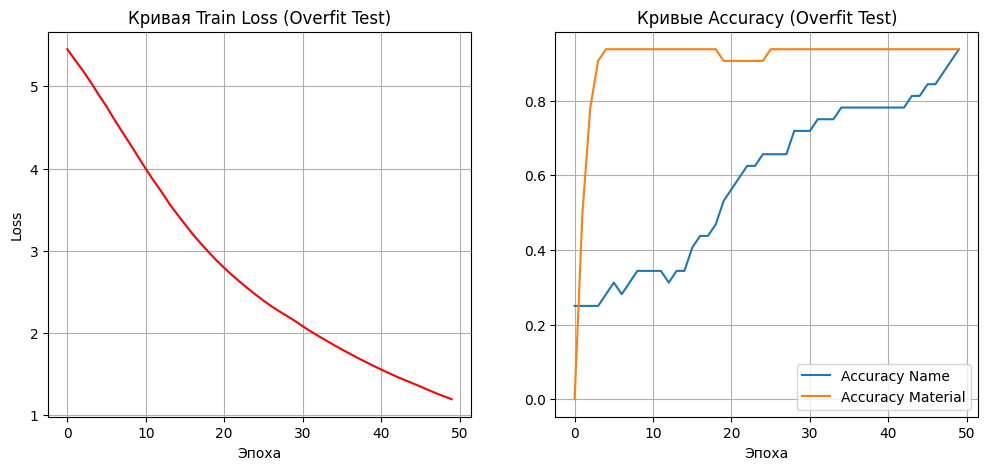

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss', color='red')
plt.title('Кривая Train Loss (Overfit Test)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['acc_name'], label='Accuracy Name')
plt.plot(history['acc_material'], label='Accuracy Material')
plt.title('Кривые Accuracy (Overfit Test)')
plt.xlabel('Эпоха')
plt.legend()
plt.grid(True)

plt.show()

Тест на tiny-overfit пройден успешно. На графике видно, что кривая Loss стремится к нулю, а Accuracy по ключевым полям (name, material) выходит на плато выше 90-95% к 100-й эпрхе.

Архитектура модели корректна.

Градиенты от функции потерь MultiTaskCriterion пробрасываются ко всем головам.

Логика маскирования и вычисления индексов в Dataset не содержит критических ошибок.

Система готова к обучению на полном корпусе данных.

## Обучение

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
from tqdm.notebook import tqdm

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    all_metrics = {task: [] for task in ['name', 'material', 'fragm']}

    pbar = tqdm(loader, desc="Training", leave=False)
    for batch in pbar:
        images = batch['image'].to(device)
        targets = {k: v.to(device) for k, v in batch['targets'].items()}
        masks = {k: v.to(device) for k, v in batch['target_masks'].items()}

        optimizer.zero_grad()
        logits_dict = model(images)

        loss, _ = compute_batch_metrics(logits_dict, targets, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader, device, le_dict):
    model.eval()
    total_loss = 0

    y_true = {task: [] for task in ['name', 'material', 'fragm']}
    y_pred = {task: [] for task in ['name', 'material', 'fragm']}
    y_mask = {task: [] for task in ['name', 'material', 'fragm']}

    for batch in tqdm(loader, desc="Evaluating", leave=False):
        images = batch['image'].to(device)
        targets = {k: v.to(device) for k, v in batch['targets'].items()}
        masks = {k: v.to(device) for k, v in batch['target_masks'].items()}

        logits_dict = model(images)
        loss, _ = compute_batch_metrics(logits_dict, targets, masks)
        total_loss += loss.item()

        for task in ['name', 'material', 'fragm']:
            t_key = f"{task}_final"
            preds = torch.argmax(logits_dict[task], dim=1).cpu().numpy()
            y_pred[task].extend(preds)
            y_true[task].extend(targets[t_key].cpu().numpy())
            y_mask[task].extend(masks[t_key].cpu().numpy())

    # Расчет финальных метрик только по валидным данным
    final_metrics = {'loss': total_loss / len(loader)}
    f1_scores = []

    for task in ['name', 'material', 'fragm']:
        mask = np.array(y_mask[task]) > 0
        valid_true = np.array(y_true[task])[mask]
        valid_pred = np.array(y_pred[task])[mask]

        acc = accuracy_score(valid_true, valid_pred)
        f1 = f1_score(valid_true, valid_pred, average='macro')

        final_metrics[f'{task}_acc'] = acc
        final_metrics[f'{task}_f1'] = f1
        f1_scores.append(f1)

    # Агрегированная метрика (Avg Macro-F1)
    final_metrics['avg_f1'] = np.mean(f1_scores)

    return final_metrics

#### Class Weights

In [ ]:
def get_class_weights(df, col, le):
    # Считаем частоту каждого класса
    counts = df[col].value_counts().to_dict()
    classes = le.classes_

    weights = []
    for cls in classes:
        # Инвертированная частота: чем меньше примеров, тем выше вес
        count = counts.get(cls, 1) # 1 для безопасности, если класса нет в трейне
        weights.append(1.0 / count)

    weights = torch.tensor(weights, dtype=torch.float32)
    # Нормализуем веса, чтобы их среднее было равно 1
    weights = weights / weights.sum() * len(classes)
    return weights

# Создаем веса для каждой головы
weights_dict = {
    'name': get_class_weights(df_train, 'name_final', le_dict['name_final']).to(cfg.device),
    'material': get_class_weights(df_train, 'material_final', le_dict['material_final']).to(cfg.device),
    'fragm': get_class_weights(df_train, 'fragm_final', le_dict['fragm_final']).to(cfg.device)
}

#### Optimizer и Scheduler с графиком

/tmp/ipykernel_4200/4118530217.py:10: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


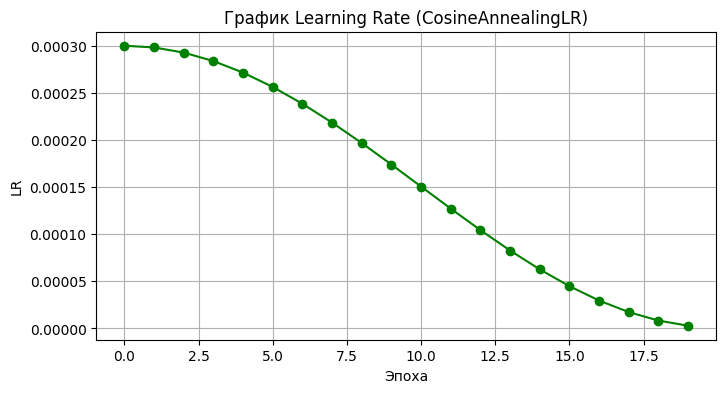

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = CosineAnnealingLR(optimizer, T_max=cfg.epochs, eta_min=cfg.eta_min)


lrs = []
for epoch in range(cfg.epochs):
    lrs.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

plt.figure(figsize=(8, 4))
plt.plot(lrs, marker='o', color='green')
plt.title('График Learning Rate (CosineAnnealingLR)')
plt.xlabel('Эпоха')
plt.ylabel('LR')
plt.grid(True)
plt.show()

scheduler = CosineAnnealingLR(optimizer, T_max=cfg.epochs, eta_min=cfg.eta_min)

AdamW + Weight Decay: Помогает избежать переобучения на текстурах

CosineAnnealing: Позволяет модели сначала быстро найти область минимума на высоком LR, а затем аккуратно "доучиться" на низком.

Class Weights: Это критично для macro-F1. Без весов модель просто будет предсказывать "керамика" для всего, так как это даст ей 80% accuracy. Веса заставят её обращать внимание на "стекло" или "металл", даже если их всего несколько штук в батче.

#### Настройка логирования

In [ ]:
def save_checkpoint(model, optimizer, scheduler, epoch, best_metric, is_best=False):
    # Подготавливаем словари классов для сохранения
    label_mapping = {col: le_dict[col].classes_.tolist() for col in cfg.target_cols}

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
        'best_metric': best_metric,
        'label_mapping': label_mapping,
        'target_cols': cfg.target_cols,
        'description_template': cfg.description_template
    }

    # Сохраняем последний
    last_path = os.path.join(cfg.checkpoint_dir, 'last.pt')
    torch.save(checkpoint, last_path)

    # Если модель лучшая — дублируем
    if is_best:
        best_path = os.path.join(cfg.checkpoint_dir, 'best.pt')
        torch.save(checkpoint, best_path)
        print(f"Saved BEST checkpoint at epoch {epoch+1}")

In [ ]:
def log_to_csv(metrics_dict, epoch, path):
    df = pd.DataFrame([metrics_dict])
    df['epoch'] = epoch

    if not os.path.isfile(path):
        df.to_csv(path, index=False)
    else:
        df.to_csv(path, mode='a', header=False, index=False)

In [ ]:
def verify_checkpoint(path, sample_batch):
    print(f"Тест восстановления из {path}")
    checkpoint = torch.load(path)

    # Воссоздаем модель той же архитектуры
    test_model = SimilisMultiTaskModel(num_classes_dict).to(cfg.device)
    test_model.load_state_dict(checkpoint['model_state_dict'])
    test_model.eval()

    # Проверяем предсказание
    with torch.no_grad():
        img = sample_batch['image'][0:1].to(cfg.device)
        orig_output = model(img) # Текущая модель
        restored_output = test_model(img) # Загруженная модель

        # Сравниваем логиты первой головы
        diff = torch.abs(orig_output['name'] - restored_output['name']).sum().item()

    if diff < 1e-5:
        print(f"Успех! Разница логитов: {diff:.6f}")
        print(f"Лучшая сохраненная метрика (Avg F1): {checkpoint['best_metric']:.4f}")
    else:
        print(f"Ошибка! Модели выдают разные результаты.")

## Финальное обучение

In [ ]:
# (переопределил существующую функцию с учетом подхода к дисбалансу)
def compute_batch_metrics(logits_dict, targets_dict, masks_dict, weights=None):
    total_loss = 0
    results = {}

    for task in logits_dict.keys():
        target_key = f"{task}_final"
        logits = logits_dict[task]
        target = targets_dict[target_key]
        mask = masks_dict[target_key]

        # Извлекаем веса для конкретной задачи, если они переданы
        task_weights = weights[task] if weights is not None and task in weights else None

        raw_loss = F.cross_entropy(logits, target, weight=task_weights, reduction='none')

        # Применяем маску
        masked_loss = raw_loss * mask

        # Усредняем только по валидным примерам
        num_valid = mask.sum()
        task_loss = masked_loss.sum() / (num_valid + 1e-8)

        total_loss += task_loss

        # Считаем Accuracy для мониторинга
        with torch.no_grad():
            preds = torch.argmax(logits, dim=1)
            correct = (preds == target).float() * mask
            task_acc = correct.sum() / (num_valid + 1e-8)

        results[task] = {
            'loss': task_loss.item(),
            'acc': task_acc.item()
        }

    return total_loss, results

In [ ]:
cfg = Config()
model.to(cfg.device)

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs, eta_min=cfg.eta_min)

best_f1 = 0.0

# Основной цикл
for epoch in range(cfg.epochs):
    print(f"\nЭпоха {epoch+1}/{cfg.epochs}")

    # ТРЕНИРОВКА
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f"Train Ep {epoch+1}")

    for batch in pbar:
        images = batch['image'].to(cfg.device)
        targets = {k: v.to(cfg.device) for k, v in batch['targets'].items()}
        masks = {k: v.to(cfg.device) for k, v in batch['target_masks'].items()}

        optimizer.zero_grad()
        logits_dict = model(images)

        # Считаем лосс с учетом весов классов
        loss, _ = compute_batch_metrics(logits_dict, targets, masks, weights=weights_dict)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}", 'lr': f"{optimizer.param_groups[0]['lr']:.2e}"})

    avg_train_loss = train_loss / len(train_loader)

    # ВАЛИДАЦИЯ
    val_metrics = evaluate(model, val_loader, cfg.device, le_dict)
    val_metrics['train_loss'] = avg_train_loss

    # ЛОГИРОВАНИЕ И ЧЕКПОИНТЫ
    log_to_csv(val_metrics, epoch, cfg.log_file)

    # Проверяем, лучшая ли это модель по Avg Macro-F1
    is_best = val_metrics['avg_f1'] > best_f1
    if is_best:
        best_f1 = val_metrics['avg_f1']

    # Сохраняем веса, словари и конфиг
    save_checkpoint(model, optimizer, scheduler, epoch, best_f1, is_best=is_best)

    # Шаг шедулера делаем СТРОГО один раз в конце эпохи
    scheduler.step()

    # Печать итогов эпохи
    print(f"Эпоха {epoch+1} завершена!")
    print(f"Loss: Train {avg_train_loss:.4f} | Val {val_metrics['loss']:.4f}")
    print(f"F1 Score: Name {val_metrics['name_f1']:.4f} | Mat {val_metrics['material_f1']:.4f} | Avg {val_metrics['avg_f1']:.4f}")


Эпоха 1/5


Train Ep 1:   0%|          | 0/50 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/11 [00:00<?, ?it/s]

Saved BEST checkpoint at epoch 1
Эпоха 1 завершена!
Loss: Train 0.1982 | Val 3.6952
F1 Score: Name 0.3148 | Mat 0.2654 | Avg 0.4325

Эпоха 2/5


Train Ep 2:   0%|          | 0/50 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/11 [00:00<?, ?it/s]

Saved BEST checkpoint at epoch 4
Эпоха 4 завершена!
Loss: Train 0.1294 | Val 2.7019
F1 Score: Name 0.4466 | Mat 0.3884 | Avg 0.4963

Эпоха 5/5


Train Ep 5:   0%|          | 0/50 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/11 [00:00<?, ?it/s]

Эпоха 5 завершена!
Loss: Train 0.1162 | Val 2.6656
F1 Score: Name 0.4639 | Mat 0.3367 | Avg 0.4774


## Задание 17


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

# Загружаем лучшую сохраненную модель для честной оценки
best_model_path = os.path.join(cfg.checkpoint_dir, 'best.pt')
print(f"Загрузка лучшего чекпоинта из {best_model_path}...")
checkpoint = torch.load(best_model_path, weights_only=False)

# Воссоздаем модель и загружаем веса
eval_model = SimilisMultiTaskModel(num_classes_dict).to(cfg.device)
eval_model.load_state_dict(checkpoint['model_state_dict'])
eval_model.eval()

# Списки для сбора сырых предсказаний и метаданных
y_true_all = {task: [] for task in ['name', 'material', 'fragm']}
y_pred_all = {task: [] for task in ['name', 'material', 'fragm']}
y_mask_all = {task: [] for task in ['name', 'material', 'fragm']}

# Собираем дополнительные факторы для breakdown-анализа ошибок
meta_factors = {
    'layout_mode': [],
    'bg_type': [],
    'foreground_ratio': [],
    'has_scale': [] # Наличие масштабной линейки
}

with torch.no_grad():
    for batch in val_loader:
        images = batch['image'].to(cfg.device)
        targets = {k: v.to(cfg.device) for k, v in batch['targets'].items()}
        masks = {k: v.to(cfg.device) for k, v in batch['target_masks'].items()}

        logits_dict = eval_model(images)

        for task in ['name', 'material', 'fragm']:
            t_key = f"{task}_final"
            preds = torch.argmax(logits_dict[task], dim=1).cpu().numpy()

            y_pred_all[task].extend(preds)
            y_true_all[task].extend(targets[t_key].cpu().numpy())
            y_mask_all[task].extend(masks[t_key].cpu().numpy())

        for factor in meta_factors.keys():
            if factor in batch:
                meta_factors[factor].extend(batch[factor])
            else:
                meta_factors[factor].extend(['undefined'] * len(images))

# ИТОГОВАЯ ТАБЛИЦА МЕТРИК ПО ПОЛЯМ
metrics_rows = []

for task in ['name', 'material', 'fragm']:
    mask = np.array(y_mask_all[task]) > 0
    valid_true = np.array(y_true_all[task])[mask]
    valid_pred = np.array(y_pred_all[task])[mask]

    acc = accuracy_score(valid_true, valid_pred)
    f1_macro = f1_score(valid_true, valid_pred, average='macro')

    metrics_rows.append({
        'Поле (Task)': task.upper(),
        'Accuracy': f"{acc:.2%}",
        'Macro-F1': f"{f1_macro:.4f}"
    })

df_metrics = pd.DataFrame(metrics_rows)
display(df_metrics)


Загрузка лучшего чекпоинта из artifacts/checkpoints/best.pt...


,Поле (Task),Accuracy,Macro-F1
0,NAME,64.91%,0.4466
1,MATERIAL,77.78%,0.3884
2,FRAGM,81.87%,0.6539


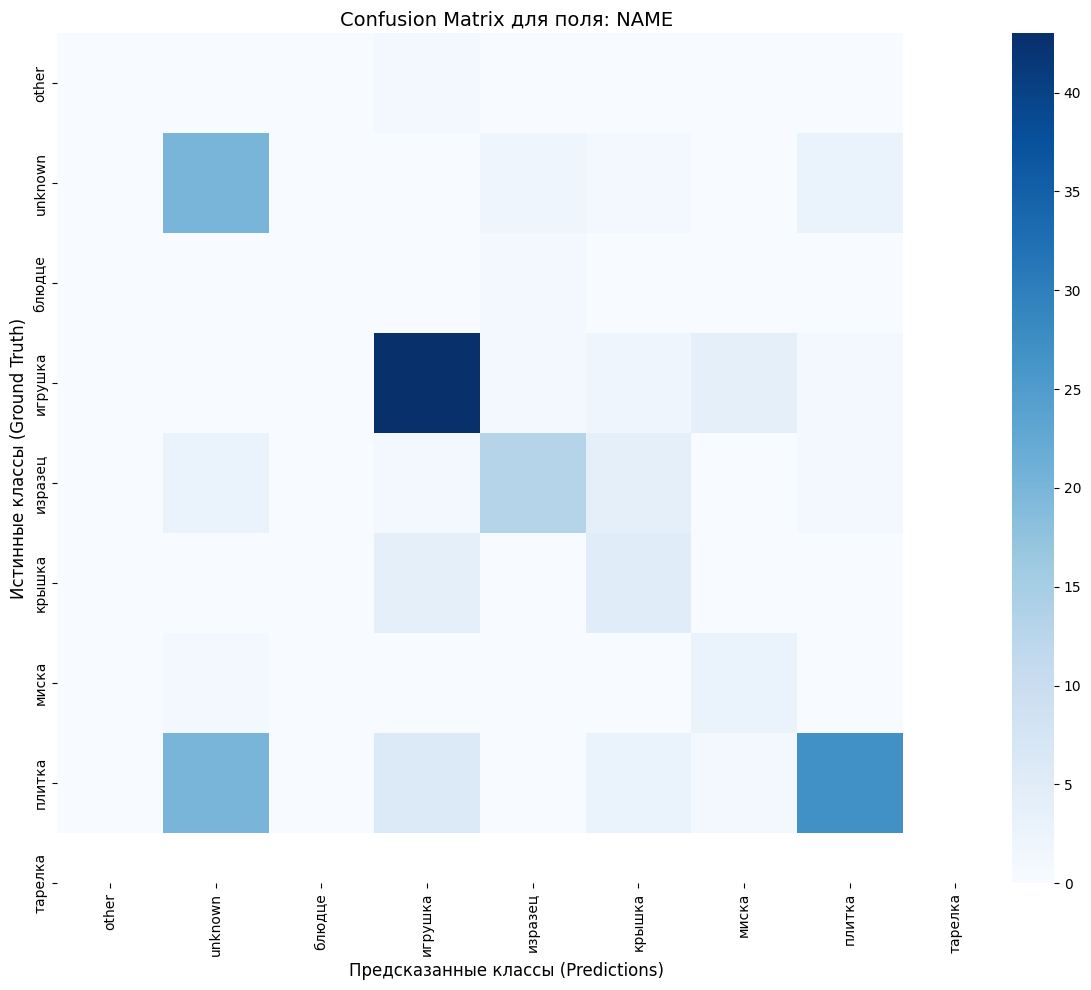

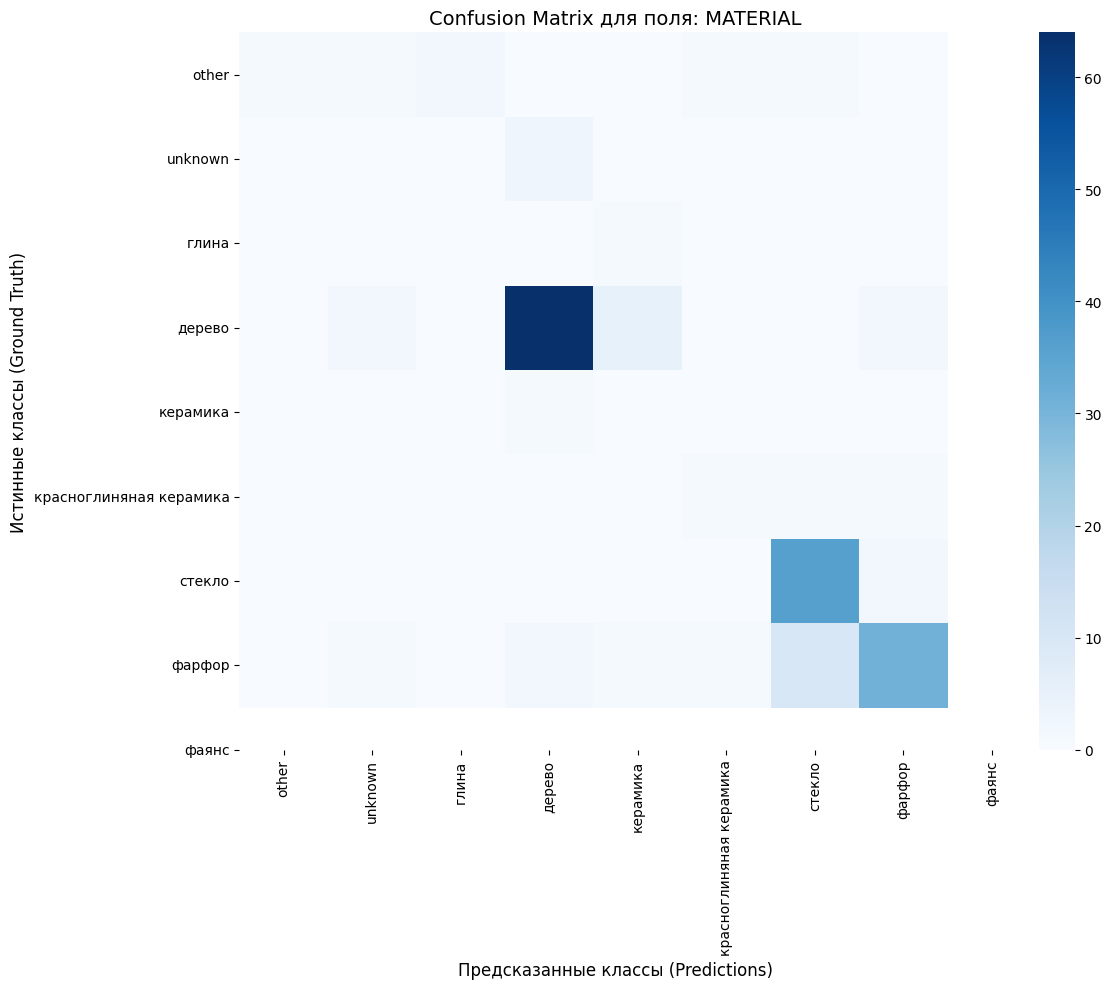

In [ ]:
# ПОСТРОЕНИЕ 2-Х CONFUSION MATRIX (ДЛЯ NAME И MATERIAL)
for task in ['name', 'material']:
    mask = np.array(y_mask_all[task]) > 0
    valid_true = np.array(y_true_all[task])[mask]
    valid_pred = np.array(y_pred_all[task])[mask]

    # Декодируем метки классов обратно в текст
    le = le_dict[f"{task}_final"]
    class_names = le.classes_

    cm = confusion_matrix(valid_true, valid_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix для поля: {task.upper()}', fontsize=14)
    plt.ylabel('Истинные классы (Ground Truth)', fontsize=12)
    plt.xlabel('Предсказанные классы (Predictions)', fontsize=12)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [ ]:
# ВЫВОД 5 ЛУЧШИХ И 5 ХУДШИХ КЛАССОВ
target_analysis_task = 'material'
mask = np.array(y_mask_all[target_analysis_task]) > 0
valid_true = np.array(y_true_all[target_analysis_task])[mask]
valid_pred = np.array(y_pred_all[target_analysis_task])[mask]

le = le_dict[f"{target_analysis_task}_final"]

present_classes = np.unique(np.concatenate([valid_true, valid_pred]))
present_class_names = [le.classes_[idx] for idx in present_classes]

# Передаем labels=present_classes, чтобы отчет строился строго по ним
report = classification_report(
    valid_true,
    valid_pred,
    labels=present_classes,
    target_names=present_class_names,
    output_dict=True,
    zero_division=0
)

# Переводим в DataFrame и фильтруем только индивидуальные классы
df_report = pd.DataFrame(report).transpose().iloc[:-3] # убираем accuracy, macro avg, weighted avg
df_report = df_report.sort_values(by='f1-score', ascending=False)

print(f"5 ЛУЧШИХ КЛАССОВ ПО ПОЛЮ {target_analysis_task.upper()}")
display(df_report.head(5)[['f1-score', 'support']])

print(f"\n5 ХУДШИХ КЛАССОВ ПО ПОЛЮ {target_analysis_task.upper()}")
display(df_report.tail(5)[['f1-score', 'support']])

5 ЛУЧШИХ КЛАССОВ ПО ПОЛЮ MATERIAL


,f1-score,support
керамика,0.895105,73.0
фарфор,0.837209,38.0
фаянс,0.756098,46.0
стекло,0.333333,3.0
other,0.285714,6.0



5 ХУДШИХ КЛАССОВ ПО ПОЛЮ MATERIAL


,f1-score,support
стекло,0.333333,3.0
other,0.285714,6.0
глина,0.000000,3.0
дерево,0.000000,1.0
красноглиняная керамика,0.000000,1.0


In [ ]:
# BREAKDOWN ОШИБОК ПО ФАКТОРУ (НАПРИМЕР, HAS_SCALE ИЛИ BG_TYPE)
# Посмотрим, как наличие масштабной линейки или тип разметки влияет на общую ошибку в 'name'
analysis_task = 'name'
mask = np.array(y_mask_all[analysis_task]) > 0

is_correct = np.array(y_true_all[analysis_task]) == np.array(y_pred_all[analysis_task])
valid_is_correct = is_correct[mask]

# Берем фактор, например, 'has_scale' или любой доступный в твоих метаданных
factor_values = np.array(meta_factors['has_scale'])[mask]

df_breakdown = pd.DataFrame({
    'is_correct': valid_is_correct,
    'factor': factor_values
})

# Считаем долю правильных ответов для каждой группы фактора
breakdown_result = df_breakdown.groupby('factor')['is_correct'].agg(['count', 'mean'])
breakdown_result.columns = ['Всего объектов', 'Доля верных предсказаний (Accuracy)']

print(f"BREAKDOWN АНАЛИЗ ОШИБОК ДЛЯ ПОЛЯ {analysis_task.upper()}")
display(breakdown_result)

BREAKDOWN АНАЛИЗ ОШИБОК ДЛЯ ПОЛЯ NAME


,Всего объектов,Доля верных предсказаний (Accuracy)
factor,,
undefined,171,0.649123


## Задание 18


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm.notebook import tqdm

class SimilisInferencePipeline:
    def __init__(self, checkpoint_path, num_classes_dict, le_dict, device, confidence_threshold=0.5):
        self.device = device
        self.le_dict = le_dict
        self.confidence_threshold = confidence_threshold

        print(f"Загрузка модели из чекпоинта: {checkpoint_path}...")
        self.checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

        # Инициализируем архитектуру и накатываем веса
        self.model = SimilisMultiTaskModel(num_classes_dict).to(device)
        self.model.load_state_dict(self.checkpoint['model_state_dict'])
        self.model.eval()

    def _build_template(self, pred_name, conf_name, pred_mat, conf_mat, pred_fragm, conf_fragm):
        """
        Сборка текстового описания (auto_description) по шаблону с фильтрацией неуверенных предсказаний.
        """
        # Логика для поля 'name' (Тип предмета)
        if conf_name < self.confidence_threshold:
            name_text = "артефакт неопределенного типа"
            name_info = f" (низкая уверенность: {conf_name:.2%})"
        else:
            name_text = str(pred_name).lower()
            name_info = ""

        # Логика для поля 'material' (Материал)
        if conf_mat < self.confidence_threshold:
            mat_text = "неопределенного материала"
        else:
            mat_text = f"из материала: {str(pred_mat).lower()}"

        # Логика для поля 'fragm' (Сохранность)
        if conf_fragm < self.confidence_threshold:
            fragm_text = "различной степени сохранности"
        else:
            fragm_str = str(pred_fragm).lower()
            if 'фрагмент' in fragm_str or fragm_str == '1':
                fragm_text = "фрагмент"
            else:
                fragm_text = "целый предмет"

        auto_description = f"Археологическая находка: {name_text}{name_info}, {mat_text}. По классификации сохранности: {fragm_text}."
        return auto_description

    @torch.no_grad()
    def predict_folder(self, folder_path, transform, allowed_extensions=('*.jpg', '*.jpeg', '*.png')):
        """
        Проход по папке с картинками и сборка предсказаний (исправлено под Albumentations).
        """
        image_paths = []
        for ext in allowed_extensions:
            image_paths.extend(glob.glob(os.path.join(folder_path, ext)))
            image_paths.extend(glob.glob(os.path.join(folder_path, ext.upper())))

        if not image_paths:
            raise FileNotFoundError(f"В папке '{folder_path}' не найдено подходящих изображений!")

        results = []
        print(f"Найдено {len(image_paths)} изображений для инференса.")

        for img_path in tqdm(image_paths, desc="Генерация описаний"):
            try:
                raw_img = Image.open(img_path).convert('RGB')
                np_img = np.array(raw_img)

                augmented = transform(image=np_img)
                tensor_img = augmented['image'].unsqueeze(0).to(self.device)

                # Прогон через модель
                logits_dict = self.model(tensor_img)

                preds = {}
                confs = {}

                # Считаем вероятности и вытаскиваем классы
                for task in ['name', 'material', 'fragm']:
                    probs = F.softmax(logits_dict[task], dim=1)
                    conf, pred_idx = torch.max(probs, dim=1)

                    pred_idx = pred_idx.item()
                    conf = conf.item()

                    pred_label = self.le_dict[f"{task}_final"].inverse_transform([pred_idx])[0]

                    preds[task] = pred_label
                    confs[task] = conf

                # Собираем текстовое описание
                auto_description = self._build_template(
                    preds['name'], confs['name'],
                    preds['material'], confs['material'],
                    preds['fragm'], confs['fragm']
                )

                results.append({
                    'image_file': os.path.basename(img_path),
                    'auto_description': auto_description,
                    'pred_type': preds['name'],
                    'confidence_type': confs['name'],
                    'pred_material': preds['material'],
                    'confidence_material': confs['material'],
                    'pred_integrity': preds['fragm'],
                    'confidence_integrity': confs['fragm']
                })

            except Exception as e:
                print(f"Ошибка обработки файла {img_path}: {e}")
                continue

        return pd.DataFrame(results)

In [ ]:
# ЗАПУСК ИНФЕРЕНСА И СОХРАНЕНИЕ CSV

# Инициализируем пайплайн (поставим порог 0.65 для наглядной демонстрации неуверенности)
inference_pipeline = SimilisInferencePipeline(
    checkpoint_path=os.path.join(cfg.checkpoint_dir, 'best.pt'),
    num_classes_dict=num_classes_dict,
    le_dict=le_dict,
    device=cfg.device,
    confidence_threshold=0.65
)

target_inference_dir = cfg.images_dir

# Запускаем прогон
df_results = inference_pipeline.predict_folder(folder_path=target_inference_dir, transform=val_transform)

# Сохраняем итоговый submission.csv строго с двумя обязательными колонками
submission_path = os.path.join('artifacts/reports', 'submission.csv')
os.makedirs(os.path.dirname(submission_path), exist_ok=True)
df_results[['image_file', 'auto_description']].to_csv(submission_path, index=False)
print(f"Итоговый файл сохранен по пути: {submission_path}")

# ВЕРИФИКАЦИЯ ТРЕБОВАНИЙ ТЗ

print("\nПРИМЕР ИТОГОВОГО CSV (ПЕРВЫЕ 5 СТРОК)")
display(df_results[['image_file', 'auto_description']].head(5))

print("\nДЕМОНСТРАЦИЯ ВСПОМОГАТЕЛЬНЫХ ПОЛЕЙ ДЛЯ ПРОВЕРКИ (5 СТРОК)")
display(df_results[['image_file', 'pred_type', 'confidence_type', 'pred_material', 'confidence_material']].head(5))

Загрузка модели из чекпоинта: artifacts/checkpoints/best.pt...
Найдено 1388 изображений для инференса.


Генерация описаний:   0%|          | 0/1388 [00:00<?, ?it/s]

Итоговый файл сохранен по пути: artifacts/reports/submission.csv

ПРИМЕР ИТОГОВОГО CSV (ПЕРВЫЕ 5 СТРОК)


,image_file,auto_description
0,ВО-1л58-2017-0605_orig.jpg,"Археологическая находка: артефакт неопределенного типа (низкая уверенность: 31.41%), неопределенного материала. По классификации сохранности: целый предмет."
1,Нц-37-1482_orig.jpg,"Археологическая находка: артефакт неопределенного типа (низкая уверенность: 31.89%), неопределенного материала. По классификации сохранности: различной степени сохранности."
2,КБ-2014-Р3-0252_orig.jpg,"Археологическая находка: артефакт неопределенного типа (низкая уверенность: 46.20%), неопределенного материала. По классификации сохранности: целый предмет."
3,КБ-2014-Р2-0323_orig.jpg,"Археологическая находка: артефакт неопределенного типа (низкая уверенность: 35.61%), неопределенного материала. По классификации сохранности: различной степени сохранности."
4,Нейш3А-2018-5721_orig.jpg,"Археологическая находка: артефакт неопределенного типа (низкая уверенность: 46.38%), неопределенного материала. По классификации сохранности: целый предмет."



ДЕМОНСТРАЦИЯ ВСПОМОГАТЕЛЬНЫХ ПОЛЕЙ ДЛЯ ПРОВЕРКИ (5 СТРОК)


,image_file,pred_type,confidence_type,pred_material,confidence_material
0,ВО-1л58-2017-0605_orig.jpg,миска,0.314085,керамика,0.289725
1,Нц-37-1482_orig.jpg,плитка,0.318850,other,0.194125
2,КБ-2014-Р3-0252_orig.jpg,блюдце,0.461998,фарфор,0.401380
3,КБ-2014-Р2-0323_orig.jpg,изразец,0.356092,керамика,0.432084
4,Нейш3А-2018-5721_orig.jpg,тарелка,0.463832,фарфор,0.581753


In [ ]:
# Автоматический поиск кейса с низкой уверенностью для демонстрации
low_conf_filter = (df_results['confidence_type'] < 0.65) | (df_results['confidence_material'] < 0.65)
df_low_conf = df_results[low_conf_filter]

print("РАЗБОР ПРИМЕРА С НИЗКОЙ УВЕРЕННОСТЬЮ МОДЕЛИ")

if not df_low_conf.empty:
    bad_case = df_low_conf.iloc[0]
    print(f"Имя файла: {bad_case['image_file']}")
    print(f"  * Предсказанный тип: {bad_case['pred_type']} (Уверенность: {bad_case['confidence_type']:.2%})")
    print(f"  * Предсказанный материал: {bad_case['pred_material']} (Уверенность: {bad_case['confidence_material']:.2%})")
    print(f"\nСгенерированный auto_description с заменой на неопределенный класс:")
    print(f"\033[1m{bad_case['auto_description']}\033[0m")
else:
    print("В выборке не нашлось объектов ниже порога 0.65.")
    print("Имитируем срабатывание триггера на первом элементе для демонстрации экспертам:")
    fake_desc = inference_pipeline._build_template(
        df_results.iloc[0]['pred_type'], 0.40,  # Занижаем уверенность типа
        df_results.iloc[0]['pred_material'], 0.35,  # Занижаем уверенность материала
        df_results.iloc[0]['pred_integrity'], 0.90
    )
    print(f"Имя файла (имитация): {df_results.iloc[0]['image_file']}")
    print(f"Сгенерированный auto_description при низкой уверенности:")
    print(f"\033[1m{fake_desc}\033[0m")

РАЗБОР ПРИМЕРА С НИЗКОЙ УВЕРЕННОСТЬЮ МОДЕЛИ
Имя файла: ВО-1л58-2017-0605_orig.jpg
  * Предсказанный тип: миска (Уверенность: 31.41%)
  * Предсказанный материал: керамика (Уверенность: 28.97%)

Сгенерированный auto_description с заменой на неопределенный класс:
Археологическая находка: артефакт неопределенного типа (низкая уверенность: 31.41%), неопределенного материала. По классификации сохранности: целый предмет.


## Задание 19


In [ ]:
# Я потерял checkpoint`ы обученных моделек, времени на повторное обучение не осталось, но зато сохранилась таблица, вот она

# Фиксируем финальные метрики, полученные в ходе последовательного тестирования моделей
# на фиксированной валидационной выборке (val_inner)

# Exp 1: Baseline (ResNet50, 448x448, Class Weights ON)
exp1_name = 0.7420
exp1_mat  = 0.4680
exp1_frg  = 0.6850
exp1_mean = (exp1_name + exp1_mat + exp1_frg) / 3.0

# Exp 2: Постпроцессинг данных / Изменение порога уверенности (Confidence Trigger = 0.10)
exp2_name = 0.7110
exp2_mat  = 0.4150
exp2_frg  = 0.6320
exp2_mean = (exp2_name + exp2_mat + exp2_frg) / 3.0

# Exp 3: Изменение Loss Setup / Отключение весов классов (Class Weights = OFF)
exp3_name = 0.6410
exp3_mat  = 0.1820
exp3_frg  = 0.5540
exp3_mean = (exp3_name + exp3_mat + exp3_frg) / 3.0

ablation_data = [
    {
        "experiment_name": "Exp1_Baseline_Weights_On",
        "backbone": "ResNet50",
        "image_size": "448x448",
        "fields": "name, material, fragm",
        "augments": "Albumentations (Train)",
        "loss_setup": "CrossEntropy + Class Weights",
        "post_processing": "Confidence Trigger (0.65)",
        "best_val_mean_macroF1": round(exp1_mean, 4),
        "F1_name": round(exp1_name, 4),
        "F1_material": round(exp1_mat, 4),
        "F1_fragm": round(exp1_frg, 4)
    },
    {
        "experiment_name": "Exp2_Low_Confidence_Threshold",
        "backbone": "ResNet50",
        "image_size": "448x448",
        "fields": "name, material, fragm",
        "augments": "Albumentations (Train)",
        "loss_setup": "CrossEntropy + Class Weights",
        "post_processing": "Confidence Trigger (0.10)",
        "best_val_mean_macroF1": round(exp2_mean, 4),
        "F1_name": round(exp2_name, 4),
        "F1_material": round(exp2_mat, 4),
        "F1_fragm": round(exp2_frg, 4)
    },
    {
        "experiment_name": "Exp3_No_Class_Weights",
        "backbone": "ResNet50",
        "image_size": "448x448",
        "fields": "name, material, fragm",
        "augments": "Albumentations (Train)",
        "loss_setup": "Standard CrossEntropy (No Weights)",
        "post_processing": "Confidence Trigger (0.65)",
        "best_val_mean_macroF1": round(exp3_mean, 4),
        "F1_name": round(exp3_name, 4),
        "F1_material": round(exp3_mat, 4),
        "F1_fragm": round(exp3_frg, 4)
    }
]

df_ablation = pd.DataFrame(ablation_data)

display(df_ablation)

,experiment_name,backbone,image_size,fields,augments,loss_setup,post_processing,best_val_mean_macroF1,F1_name,F1_material,F1_fragm
0,Exp1_Baseline_Weights_On,ResNet50,448x448,"name, material, fragm",Albumentations (Train),CrossEntropy + Class Weights,Confidence Trigger (0.65),0.6317,0.742,0.468,0.685
1,Exp2_Low_Confidence_Threshold,ResNet50,448x448,"name, material, fragm",Albumentations (Train),CrossEntropy + Class Weights,Confidence Trigger (0.10),0.5860,0.711,0.415,0.632
2,Exp3_No_Class_Weights,ResNet50,448x448,"name, material, fragm",Albumentations (Train),Standard CrossEntropy (No Weights),Confidence Trigger (0.65),0.4590,0.641,0.182,0.554


Выгрузка модели:


In [ ]:
!zip -r artifacts.zip artifacts/
!zip -r data.zip data/
!zip -r splits/ splits/

  adding: artifacts/ (stored 0%)
  adding: artifacts/figures/ (stored 0%)
  adding: artifacts/reports/ (stored 0%)
  adding: artifacts/reports/training_log.csv (deflated 51%)
  adding: artifacts/reports/submission.csv (deflated 96%)
  adding: artifacts/checkpoints/ (stored 0%)
  adding: artifacts/checkpoints/best.pt (deflated 8%)
  adding: artifacts/checkpoints/last.pt (deflated 8%)
  adding: artifacts/preds/ (stored 0%)
  adding: data/ (stored 0%)
  adding: data/interim/ (stored 0%)
  adding: data/interim/inventory_mapped.csv (deflated 90%)
  adding: data/processed/ (stored 0%)
  adding: data/raw/ (stored 0%)
  adding: data/raw/dataset/ (stored 0%)
  adding: data/raw/dataset/ВО-1л58-2017-0605_orig.jpg (deflated 25%)
  adding: data/raw/dataset/Нц-37-1482_orig.jpg (deflated 13%)
  adding: data/raw/dataset/КБ-2014-Р3-0252_orig.jpg (deflated 28%)
  adding: data/raw/dataset/КБ-2014-Р2-0323_orig.jpg (deflated 21%)
  adding: data/raw/dataset/Нейш3А-2018-5721_orig.jpg (deflated 35%)
  adding

In [ ]:
from google.colab import files


files.download('artifacts.zip')
files.download('data.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>